# Tarang v9 — Diagnostic-First Iteration

**Inherits:** v8.7 routing fix (gate N vs SV, dual independent SV heads V/S vs rest, 2-lead ECG + 7 RR features, 130-sample window).

**v9 plan (locked after critical review):**

The v8.7 roadmap proposed eight forward-going changes (S-recall floor, drop double-balancing, hard-N re-mining, focal loss, widen RR branch, hard-S mining, gate capacity, window resize) plus a metrics logger.

Critical review concluded:

1. Several recommendations were architected against the wrong objective (gate-stage metrics instead of end-of-cascade Macro F1).
2. One recommendation (#5 widen RR branch) reflects a misunderstanding of multi-branch fusion dynamics — diagnostic first, lever second.
3. One recommendation (#8 "dual-lead") was factually wrong — already 2-lead since v1.
4. Several were parked behind cheap diagnostics that had not been run.

The locked v9 plan reorders the work: **diagnose first, retrain only after the diagnostics identify which knob is stuck.**

### Locked v9 plan

**Step 0 (now, before anything else runs):** metrics.json logger — seeds, full loss curves, every hyperparameter including `N_SHARE_TARGET`, and per-patient S **recall and precision separately**, not F1.

**Diagnostics (CPU-only / sub-1-GPU-hour), in order:**
1. Per-patient S recall/precision breakdown on current v8.7 — four possible regimes (low recall concentrated → data-quality issue; low recall spread → systematic model failure; low precision concentrated → those patients' N beats look S-like; low precision spread → SV head's N-rejection is globally weak).
2. Repartition: 3-fold internal val inside the 18 train patients (~6 patients/fold). Check INCART-vs-MIT-BIH-val distribution shift regardless; keep INCART-as-calibration as fallback only if step 3 is still unstable on the larger fold.
3. Joint `(gate_thr, V_thr, S_thr)` sweep on cascade Macro F1, on the new internal val, with a patient-level bootstrap stability check — report the spread honestly even at n≈6, don't pretend it's a clean CI.
4. Blinded inspection of 50–70 misclassified S beats — record ID, model confidence, and predicted class hidden before categorizing as underfitting / ambiguous / label noise / clipped-context.
5. RR ablation + RR-only logistic baseline.

**First GPU-heavy step — sweep → retrain → re-sweep loop, capped at 2 iterations:**
6. Re-mine N at step 3's threshold, sweeping `N_SHARE_TARGET ∈ {0.20, 0.35, 0.50}` as a 4th dimension (3 SV retrains). For each, re-run step 3's joint sweep on the *new* SV head — old thresholds are stale the moment the head changes. Pick the `(N_SHARE_TARGET, gate_thr, V_thr, S_thr)` combination with the best stable cascade Macro F1. If that pick still meaningfully shifts the SV training distribution from what was used to build it, repeat once more, then stop and report wherever it lands.

**Conditional, gated on steps 4–5, each tested alone:**
- RR branch: widen only if RR is used-but-underweighted *and* no gradient drowning. If drowning, the lever is PCGrad/GradNorm, not width.
- Hard-S mining: only if step 4 shows mostly underfitting.
- Focal loss (γ swept, vs α-balanced BCE): only if step 4 doesn't show heavy label noise.
- Gate double-balancing ablation: independent, gate-only, can run anytime.

**Still parked:** gate capacity, window re-extraction (gated behind step 4's clipped-context finding), flash/quantization size.

### What changed from v8.7

- v8.7's `gate_s_recall_floor` heuristic (Phase 1 #1) is **replaced** by the joint threshold sweep (Step 3). Optimizing gate-stage S recall was the wrong objective; end-of-cascade Macro F1 is what we report.
- v8.7's per-head sequential V-then-S threshold sweep is **replaced** by the joint sweep. Sequential selection cannot escape local optima introduced by V/S interaction.
- v8.7's hard-N mining at fixed `N_SHARE_TARGET=0.35` is **generalized** to a sweep (Step 6). The 0.35 value was author fiat; the project has never tested sensitivity.
- v8.7's `Lambda → Reshape` weight transplant (cell 17) is **removed**. With `FORCE_GATE_RETRAIN=True` and `FORCE_SV_RETRAIN=True`, the transplant is vestigial — the next training cell deletes the checkpoint anyway.


## Step 0 — Setup, paths, seeds, and the v9 run config

Every hyperparameter that could affect a result lives in `RUN_CONFIG` and is serialized into every `metrics_*.json`. If a number isn't in `RUN_CONFIG`, it isn't a controlled variable.

In [1]:
import os
import json
import glob
import hashlib
import warnings
from collections import Counter, defaultdict
from datetime import datetime
from pathlib import Path

import wfdb
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.signal import resample_poly
from scipy.stats import wasserstein_distance

import tensorflow as tf
from tensorflow.keras import regularizers

import sklearn
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import (classification_report, confusion_matrix, f1_score,
                              roc_auc_score, roc_curve, precision_recall_curve,
                              recall_score, precision_score, accuracy_score)
from sklearn.linear_model import LogisticRegression
from sklearn.utils import class_weight

warnings.filterwarnings('ignore')

# ── GPU memory ───────────────────────────────────────────────────────────────
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    for gpu in gpus:
        tf.config.experimental.set_memory_growth(gpu, True)
    print(f"GPU memory growth enabled for {len(gpus)} GPU(s)")

# ── Paths (inherited from v8.7) ──────────────────────────────────────────────
BASE = 'C:/MMD Public/Hackathons/Team Ocelleon/dataset'

def find_dir(base, *candidates):
    for c in candidates:
        p = os.path.join(base, c)
        if os.path.isdir(p): return p
    for c in candidates:
        for variant in [c, c.lower(), c.upper(), c.title()]:
            p = os.path.join(base, variant)
            if os.path.isdir(p): return p
    return os.path.join(base, candidates[0])

MITBIH_PATH = find_dir(BASE, 'mit-bih-arrhythmia-database-1.0.0', 'mitbih')
SVDB_PATH   = find_dir(BASE, 'mit-bih-supraventricular-arrhythmia-database-1.0.0', 'svdb')
INCART_PATH = find_dir(BASE, 'incartdb', 'incart')
AFDB_PATH   = find_dir(BASE, 'afdb', 'AFDB', 'mit-bih-atrial-fibrillation-database-1.0.0')

OUTPUTS_DIR        = 'outputs_v9'
GATE_KERAS         = f'{OUTPUTS_DIR}/tarang_gate_v8_7.keras'   # architecture identical to v8.6
SV_KERAS_BASELINE  = f'{OUTPUTS_DIR}/tarang_sv_v8_7_baseline.keras'  # N_SHARE_TARGET=0.35
GATE_HISTORY       = f'{OUTPUTS_DIR}/gate_history_v8_7.json'
SV_HISTORY_BASELINE= f'{OUTPUTS_DIR}/sv_history_v8_7_baseline.json'
DATA_CHECKPOINT    = f'{OUTPUTS_DIR}/data_checkpoint.npz'
METRICS_DIR        = f'{OUTPUTS_DIR}/metrics'
os.makedirs(OUTPUTS_DIR, exist_ok=True)
os.makedirs(METRICS_DIR, exist_ok=True)

# ── Sampling / window (inherited, unchanged) ─────────────────────────────────
SOURCE_FS  = 360
TARGET_FS  = 250
WINDOW_LEN = 130
WINDOW_PRE  = 65
WINDOW_POST = 65

V_RECALL_FLOOR = 0.85
N_PRECISION_FLOOR = 0.95

INCART_AVAILABLE = os.path.isdir(INCART_PATH)
AFDB_AVAILABLE   = os.path.isdir(AFDB_PATH)

# ── v9-specific config ───────────────────────────────────────────────────────
SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)

# 3-fold internal CV inside the 18 MIT-BIH train records
K_FOLDS = 3

# Joint sweep grid — coarse enough to be fast, fine enough to find the optimum
GATE_THRS = np.arange(0.10, 0.71, 0.025)   # 25 values
V_THRS    = np.arange(0.10, 0.95, 0.05)    # 17 values
S_THRS    = np.arange(0.10, 0.95, 0.05)    # 17 values
N_BOOTSTRAP = 50                            # patient-level resamples per fold

# N_SHARE_TARGET sweep (Step 6)
N_SHARE_TARGETS = [0.20, 0.35, 0.50]
MAX_LOOP_ITERS  = 2                          # sweep → retrain → re-sweep cap

# Retrain flags
FORCE_GATE_RETRAIN = True
FORCE_SV_RETRAIN   = True
FORCE_AFIB_RETRAIN = False

# Single source of truth for every tunable
RUN_CONFIG = {
    'version': 'v9.0',
    'seed': SEED,
    'window_len': WINDOW_LEN,
    'window_pre': WINDOW_PRE,
    'window_post': WINDOW_POST,
    'source_fs': SOURCE_FS,
    'target_fs': TARGET_FS,
    'v_recall_floor': V_RECALL_FLOOR,
    'n_precision_floor': N_PRECISION_FLOOR,
    'k_folds': K_FOLDS,
    'gate_thrs': list(GATE_THRS),
    'v_thrs': list(V_THRS),
    's_thrs': list(S_THRS),
    'n_bootstrap': N_BOOTSTRAP,
    'n_share_targets': N_SHARE_TARGETS,
    'max_loop_iters': MAX_LOOP_ITERS,
    'force_gate_retrain': FORCE_GATE_RETRAIN,
    'force_sv_retrain': FORCE_SV_RETRAIN,
    'force_afib_retrain': FORCE_AFIB_RETRAIN,
    'rr_branch_width': 'Dense16->Dense8',
    'conv_trunk': '4x Conv2D (16,32,48,48) + GlobalAvgPool',
    'sv_loss': 'binary_crossentropy per head',
    'sv_class_weight': 'balanced per head',
    'augmentation': 'time-shift +-3, amp 0.85-1.15, gauss noise 0.02, class-specific RR perturbation',
}

print("TensorFlow :", tf.__version__)
print(f"v9 OUTPUTS_DIR : {OUTPUTS_DIR}")
print(f"Window     : {WINDOW_LEN} samples = {WINDOW_LEN/TARGET_FS*1000:.1f} ms")
print(f"Sweep grid : {len(GATE_THRS)} gate × {len(V_THRS)} V × {len(S_THRS)} S = "
      f"{len(GATE_THRS)*len(V_THRS)*len(S_THRS)} combinations")
print(f"N_SHARE_TARGETs : {N_SHARE_TARGETS}")
print(f"Bootstrap  : {N_BOOTSTRAP} patient-level resamples per fold")


GPU memory growth enabled for 1 GPU(s)
TensorFlow : 2.10.1
v9 OUTPUTS_DIR : outputs_v9
Window     : 130 samples = 520.0 ms
Sweep grid : 25 gate × 17 V × 17 S = 7225 combinations
N_SHARE_TARGETs : [0.2, 0.35, 0.5]
Bootstrap  : 50 patient-level resamples per fold


### metrics.json logger

Saves a complete run manifest: every hyperparameter, full training history (not just final metrics), all thresholds, per-patient S recall **and** precision separately (not collapsed into F1), seed, library versions, and timestamp.

Subsequent cells call `save_run_metrics(...)` after every meaningful step. Comparing runs is then a `diff` between two JSON files, not a re-read of printouts.

In [2]:
def save_run_metrics(run_name, *, stage, gate_model=None, sv_model=None,
                    history=None, thresholds=None, cascade_eval=None,
                    per_patient=None, distribution_shift=None,
                    bootstrap_summary=None, n_share_target=None,
                    extra=None):
    """Persist a complete run manifest.

    Required keys: run_name, stage (one of: 'baseline', 'diagnostic_1_per_patient',
      'diagnostic_2_repartition', 'diagnostic_3_joint_sweep', 'diagnostic_4_inspection',
      'diagnostic_5_rr_ablation', 'loop_iter', 'conditional', 'final')
    Optional keys attach artifacts computed in that stage.
    """
    metrics = {
        'run_name': run_name,
        'stage': stage,
        'timestamp': datetime.now().isoformat(),
        'config': RUN_CONFIG,
        'library_versions': {
            'tensorflow': tf.__version__,
            'numpy': np.__version__,
            'sklearn': sklearn.__version__,
            'wfdb': getattr(wfdb, '__version__', 'unknown'),
            'pandas': pd.__version__,
        },
        'seed': SEED,
    }
    if n_share_target is not None:
        metrics['n_share_target'] = n_share_target
    if history is not None:
        metrics['history'] = {k: [float(v) for v in vals] for k, vals in history.items()}
    if thresholds is not None:
        metrics['thresholds'] = thresholds
    if cascade_eval is not None:
        # Convert numpy ints/floats to native
        metrics['cascade_eval'] = json.loads(json.dumps(cascade_eval, default=str))
    if per_patient is not None:
        metrics['per_patient'] = per_patient.to_dict(orient='records')
    if distribution_shift is not None:
        metrics['distribution_shift'] = distribution_shift
    if bootstrap_summary is not None:
        metrics['bootstrap_summary'] = bootstrap_summary
    if gate_model is not None:
        metrics['gate_param_count'] = int(gate_model.count_params())
    if sv_model is not None:
        metrics['sv_param_count'] = int(sv_model.count_params())
    if extra is not None:
        metrics['extra'] = extra
    path = f'{METRICS_DIR}/metrics_{run_name}.json'
    with open(path, 'w') as f:
        json.dump(metrics, f, indent=2, default=str)
    print(f"  ✓ metrics saved: {path}")
    return path


def load_run_metrics(run_name):
    path = f'{METRICS_DIR}/metrics_{run_name}.json'
    with open(path) as f:
        return json.load(f)


def list_run_metrics():
    return sorted(glob.glob(f'{METRICS_DIR}/metrics_*.json'))

print(f"Metrics logger ready. Manifests will be written to: {METRICS_DIR}/")


Metrics logger ready. Manifests will be written to: outputs_v9/metrics/


## Data loading (inherited from v8.7, unchanged)

Record-level inter-patient split: MIT-BIH train (18 records) / val (4 records) / test (24 records), with SVDB S+V boost in train only. INCART loaded as external generalization check (NOT used for threshold calibration unless step 3 explicitly falls back to it).

**Audit note:** patient-level split is explicit and verified — `test_mask = np.isin(recs_all, list(test_recs_set))` operates on per-beat record IDs, so a patient's beats cannot appear in both train and test. The test list overlaps the canonical de Chazal/Moody-Mark inter-patient benchmark.

In [3]:
# ── Beat mapping (AAMI EC57) ──────────────────────────────────────────────────
BEAT_MAP = {
    'N': 'N', 'L': 'N', 'R': 'N', 'e': 'N', 'j': 'N',
    'A': 'S', 'a': 'S', 'J': 'S', 'S': 'S',
    'V': 'V', 'E': 'V', 'F': 'V',
    '/': 'Q', 'f': 'Q', 'Q': 'Q',
}
CLASSES_TO_USE = ['N', 'S', 'V']

MITBIH_ALL_RECORDS = [
    100,101,102,103,104,105,106,107,108,109,
    111,112,113,114,115,116,117,118,119,121,
    122,123,124,200,201,202,203,205,207,208,
    209,210,212,213,214,215,217,219,220,221,
    222,223,228,230,231,232,233,234
]
MITBIH_TEST_RECORDS = [
    101,106,108,109,112,114,115,116,118,119,
    201,202,203,205,207,208,209,210,217,219,
    221,223,228,231,233,234
]
MITBIH_VAL_RECORDS   = [105, 124, 214, 220]
MITBIH_TRAIN_RECORDS = [r for r in MITBIH_ALL_RECORDS
                        if r not in MITBIH_TEST_RECORDS and r not in MITBIH_VAL_RECORDS]
SVDB_RECORDS = [str(i) for i in range(800, 895)]
INCART_RECORDS = [f'I{i:02d}' for i in range(1, 76)] if INCART_AVAILABLE else []

print(f"MIT-BIH train : {len(MITBIH_TRAIN_RECORDS)} records {MITBIH_TRAIN_RECORDS}")
print(f"MIT-BIH val   : {len(MITBIH_VAL_RECORDS)} records {MITBIH_VAL_RECORDS}")
print(f"MIT-BIH test  : {len(MITBIH_TEST_RECORDS)} records (held out)")


MIT-BIH train : 18 records [100, 102, 103, 104, 107, 111, 113, 117, 121, 122, 123, 200, 212, 213, 215, 222, 230, 232]
MIT-BIH val   : 4 records [105, 124, 214, 220]
MIT-BIH test  : 26 records (held out)


In [4]:
def rolling_window_normalize(signal, fs, window_seconds=30):
    window_samples = int(window_seconds * fs)
    s    = pd.Series(signal.astype(np.float64))
    roll = s.rolling(window=window_samples, min_periods=1)
    mean = roll.mean()
    std  = roll.std(ddof=0).fillna(0).clip(lower=1e-8)
    return ((s - mean) / std).values.astype(np.float32)


def compute_rr_features(peaks_sec, beat_idx):
    n = len(peaks_sec)
    i = beat_idx
    prev_idx = max(0, i - 1)
    next_idx = min(n - 1, i + 1)
    rr_prev = peaks_sec[i] - peaks_sec[prev_idx]
    rr_next = peaks_sec[next_idx] - peaks_sec[i]
    rr_ratio = rr_prev / max(rr_next, 1e-4)
    lo, hi = max(0, i - 2), min(n - 1, i + 2)
    local_rrs = np.diff(peaks_sec[lo:hi+1]).astype(np.float32)
    if len(local_rrs) == 0:
        rr_mean_5, rr_std_5 = rr_prev, 0.0
    else:
        rr_mean_5 = float(np.mean(local_rrs))
        rr_std_5  = float(np.std(local_rrs))
    compensatory_ratio = rr_next / max(rr_mean_5, 1e-4)
    prematurity_index  = rr_prev / max(rr_mean_5, 1e-4)
    return np.array([rr_prev, rr_next, rr_ratio, rr_mean_5, rr_std_5,
                      compensatory_ratio, prematurity_index], dtype=np.float32)

RR_FEATURE_NAMES = ['rr_prev', 'rr_next', 'rr_ratio', 'rr_mean_5', 'rr_std_5',
                     'compensatory_ratio', 'prematurity_index']
print(f"RR feature vector: {len(RR_FEATURE_NAMES)} features: {RR_FEATURE_NAMES}")


def load_records(db_path, record_list, source_tag, two_channel=True,
                  source_fs=SOURCE_FS, verbose=True):
    all_beats, all_rr, all_labels, all_recs = [], [], [], []
    for rec_id in record_list:
        rec_str = str(rec_id)
        try:
            record     = wfdb.rdrecord(f'{db_path}/{rec_str}')
            annotation = wfdb.rdann(f'{db_path}/{rec_str}', 'atr')
            n_channels = record.p_signal.shape[1]
            up, down = (1, 1) if source_fs == TARGET_FS else (25, 36)
            sig0 = resample_poly(record.p_signal[:, 0], up, down)
            if two_channel and n_channels > 1:
                sig1 = resample_poly(record.p_signal[:, 1], up, down)
            else:
                sig1 = sig0
            ecg_ch0 = rolling_window_normalize(sig0, TARGET_FS)
            ecg_ch1 = rolling_window_normalize(sig1, TARGET_FS)
            peak_idx = annotation.sample
            if source_fs != TARGET_FS:
                peak_idx = np.round(peak_idx * TARGET_FS / source_fs).astype(int)
            peaks_sec = peak_idx / TARGET_FS
            for k, sym in enumerate(annotation.symbol):
                if sym not in BEAT_MAP: continue
                aami = BEAT_MAP[sym]
                if aami not in CLASSES_TO_USE: continue
                center = peak_idx[k]
                lo = center - WINDOW_PRE; hi = center + WINDOW_POST
                if lo < 0 or hi >= len(ecg_ch0): continue
                beat = np.stack([ecg_ch0[lo:hi], ecg_ch1[lo:hi]], axis=-1).astype(np.float32)
                rr   = compute_rr_features(peaks_sec, k)
                all_beats.append(beat); all_rr.append(rr)
                all_labels.append(aami); all_recs.append(f'{source_tag}_{rec_str}')
        except Exception as e:
            if verbose: print(f"  [skip] {source_tag}_{rec_str}: {e}")
            continue
    if not all_beats:
        return (np.empty((0, WINDOW_LEN, 2), dtype=np.float32),
                np.empty((0, 7), dtype=np.float32),
                np.array([], dtype=object), np.array([], dtype=object))
    return (np.stack(all_beats), np.stack(all_rr),
            np.array(all_labels, dtype=object), np.array(all_recs, dtype=object))

print("load_records() defined.")


RR feature vector: 7 features: ['rr_prev', 'rr_next', 'rr_ratio', 'rr_mean_5', 'rr_std_5', 'compensatory_ratio', 'prematurity_index']
load_records() defined.


In [5]:
if os.path.exists(DATA_CHECKPOINT):
    print(f"Loading data checkpoint: {DATA_CHECKPOINT}")
    cp = np.load(DATA_CHECKPOINT, allow_pickle=True)
    mb_beats = cp['mb_beats']; mb_rr = cp['mb_rr']
    mb_labels = cp['mb_labels']; mb_recs = cp['mb_recs']
    sv_beats = cp['sv_beats']; sv_rr = cp['sv_rr']
    sv_labels = cp['sv_labels']; sv_recs = cp['sv_recs']
    print(f"  MIT-BIH: {mb_beats.shape}  classes={Counter(mb_labels)}")
    if sv_beats.size > 0:
        print(f"  SVDB   : {sv_beats.shape}  classes={Counter(sv_labels)}")
else:
    print("Loading MIT-BIH Arrhythmia Database...")
    mb_beats, mb_rr, mb_labels, mb_recs = load_records(
        MITBIH_PATH, MITBIH_ALL_RECORDS, 'mitbih', two_channel=True
    )
    print(f"\nMIT-BIH total: {mb_beats.shape}  classes={Counter(mb_labels)}")

    print("Loading SVDB (S+V boost, train-only)...")
    if os.path.isdir(SVDB_PATH):
        sv_beats, sv_rr, sv_labels, sv_recs = load_records(
            SVDB_PATH, SVDB_RECORDS, 'svdb', two_channel=True
        )
        keep_mask = sv_labels != 'N'
        sv_beats, sv_rr, sv_labels, sv_recs = (
            sv_beats[keep_mask], sv_rr[keep_mask],
            sv_labels[keep_mask], sv_recs[keep_mask]
        )
        print(f"SVDB loaded (S+V only): {sv_beats.shape}  classes={Counter(sv_labels)}")
    else:
        print(f"WARNING: SVDB not found at {SVDB_PATH}")
        sv_beats = np.empty((0, WINDOW_LEN, 2), dtype=np.float32)
        sv_rr = np.empty((0, 7), dtype=np.float32)
        sv_labels = np.array([], dtype=object)
        sv_recs = np.array([], dtype=object)

    print(f"Saving data checkpoint: {DATA_CHECKPOINT}")
    np.savez_compressed(DATA_CHECKPOINT,
        mb_beats=mb_beats, mb_rr=mb_rr, mb_labels=mb_labels, mb_recs=mb_recs,
        sv_beats=sv_beats, sv_rr=sv_rr, sv_labels=sv_labels, sv_recs=sv_recs)
    print(f"  Size: {os.path.getsize(DATA_CHECKPOINT)/1e6:.1f} MB")


Loading MIT-BIH Arrhythmia Database...

MIT-BIH total: (101426, 130, 2)  classes=Counter({'N': 90608, 'V': 8037, 'S': 2781})
Loading SVDB (S+V boost, train-only)...
  [skip] svdb_813: [Errno 2] No such file or directory: 'C:\\MMD Public\\Hackathons\\Team Ocelleon\\dataset\\mit-bih-supraventricular-arrhythmia-database-1.0.0\\813.hea'
  [skip] svdb_814: [Errno 2] No such file or directory: 'C:\\MMD Public\\Hackathons\\Team Ocelleon\\dataset\\mit-bih-supraventricular-arrhythmia-database-1.0.0\\814.hea'
  [skip] svdb_815: [Errno 2] No such file or directory: 'C:\\MMD Public\\Hackathons\\Team Ocelleon\\dataset\\mit-bih-supraventricular-arrhythmia-database-1.0.0\\815.hea'
  [skip] svdb_816: [Errno 2] No such file or directory: 'C:\\MMD Public\\Hackathons\\Team Ocelleon\\dataset\\mit-bih-supraventricular-arrhythmia-database-1.0.0\\816.hea'
  [skip] svdb_817: [Errno 2] No such file or directory: 'C:\\MMD Public\\Hackathons\\Team Ocelleon\\dataset\\mit-bih-supraventricular-arrhythmia-database-1

In [6]:
# ── Build train/val/test splits (record-level, inherited from v8.7) ──────────
X_all     = np.concatenate([mb_beats, sv_beats], axis=0)
X_rr_all  = np.concatenate([mb_rr,    sv_rr],   axis=0)
y_raw_all = np.concatenate([mb_labels, sv_labels])
recs_all  = np.concatenate([mb_recs,   sv_recs])

le = LabelEncoder()
le.fit(CLASSES_TO_USE)
y_all = le.transform(y_raw_all)
n_idx, s_idx, v_idx = int(np.where(le.classes_=='N')[0][0]), \
                      int(np.where(le.classes_=='S')[0][0]), \
                      int(np.where(le.classes_=='V')[0][0])

test_recs_set  = {f'mitbih_{r}' for r in MITBIH_TEST_RECORDS}
val_recs_set   = {f'mitbih_{r}' for r in MITBIH_VAL_RECORDS}
test_mask  = np.isin(recs_all, list(test_recs_set))
val_mask   = np.isin(recs_all, list(val_recs_set))
train_mask = ~(test_mask | val_mask)

X_train, X_rr_train, y_train, recs_train, y_train_raw = (
    X_all[train_mask], X_rr_all[train_mask], y_all[train_mask],
    recs_all[train_mask], y_raw_all[train_mask])
X_val,   X_rr_val,   y_val,   recs_val,   y_val_raw   = (
    X_all[val_mask],   X_rr_all[val_mask],   y_all[val_mask],
    recs_all[val_mask],   y_raw_all[val_mask])
X_test,  X_rr_test,  y_test,  recs_test,  y_test_raw  = (
    X_all[test_mask],  X_rr_all[test_mask],  y_all[test_mask],
    recs_all[test_mask],  y_raw_all[test_mask])

# RR normalization (computed on train only)
RR_MEAN = X_rr_train.mean(axis=0)
RR_STD  = X_rr_train.std(axis=0)
RR_STD[RR_STD < 1e-8] = 1e-8
X_rr_train_norm = (X_rr_train - RR_MEAN) / RR_STD
X_rr_val_norm   = (X_rr_val   - RR_MEAN) / RR_STD
X_rr_test_norm  = (X_rr_test  - RR_MEAN) / RR_STD

print(f"Train : {X_train.shape}  classes={Counter(y_train_raw)}  patients={len(set(recs_train))}")
print(f"Val   : {X_val.shape}    classes={Counter(y_val_raw)}    patients={len(set(recs_val))}")
print(f"Test  : {X_test.shape}   classes={Counter(y_test_raw)}   patients={len(set(recs_test))} (HELD OUT)")
print(f"LabelEncoder: {list(le.classes_)}  →  n_idx={n_idx}, s_idx={s_idx}, v_idx={v_idx}")


Train : (56621, 130, 2)  classes=Counter({'N': 31125, 'S': 13889, 'V': 11607})  patients=96
Val   : (8492, 130, 2)    classes=Counter({'N': 8017, 'V': 350, 'S': 125})    patients=4
Test  : (58467, 130, 2)   classes=Counter({'N': 51466, 'V': 6040, 'S': 961})   patients=26 (HELD OUT)
LabelEncoder: ['N', 'S', 'V']  →  n_idx=0, s_idx=1, v_idx=2


In [7]:
def augment_batch(X_c, X_rr_c, class_name, n_copies, rng=None):
    """Augment 3D ECG data (N, 130, 2) + RR features. Inherited from v8.7."""
    if rng is None:
        rng = np.random.default_rng(SEED)
    n = len(X_c)
    if n == 0 or n_copies == 0:
        return (np.empty((0,)+X_c.shape[1:], dtype=np.float32),
                np.empty((0,)+X_rr_c.shape[1:], dtype=np.float32))
    out_X = np.repeat(X_c, n_copies, axis=0)
    out_rr = np.repeat(X_rr_c, n_copies, axis=0)
    shift = rng.integers(-3, 4, size=len(out_X))
    out_X_aug = np.empty_like(out_X)
    for i, s in enumerate(shift):
        if s > 0:
            out_X_aug[i, :-s] = out_X[i, s:]; out_X_aug[i, -s:] = out_X[i, -1:]
        elif s < 0:
            out_X_aug[i, -s:] = out_X[i, :s]; out_X_aug[i, :-s] = out_X[i, :1]
        else:
            out_X_aug[i] = out_X[i]
    amp = rng.uniform(0.85, 1.15, size=(len(out_X), 1, 1)).astype(np.float32)
    out_X_aug *= amp
    out_X_aug += rng.normal(0, 0.02, size=out_X_aug.shape).astype(np.float32)
    if class_name == 'S':
        out_rr[:, 0] *= rng.uniform(0.55, 0.85, size=len(out_rr))
        out_rr[:, 1] *= rng.uniform(1.10, 1.40, size=len(out_rr))
        out_rr[:, 4] *= rng.uniform(1.20, 2.00, size=len(out_rr))
        out_rr[:, 6] = out_rr[:, 0] / np.maximum(out_rr[:, 3], 1e-4)
        out_rr[:, 5] = out_rr[:, 1] / np.maximum(out_rr[:, 3], 1e-4)
    elif class_name == 'V':
        out_rr[:, 1] *= rng.uniform(1.20, 1.60, size=len(out_rr))
        out_rr[:, 4] *= rng.uniform(1.10, 1.80, size=len(out_rr))
        out_rr[:, 6] = out_rr[:, 0] / np.maximum(out_rr[:, 3], 1e-4)
        out_rr[:, 5] = out_rr[:, 1] / np.maximum(out_rr[:, 3], 1e-4)
    return out_X_aug, out_rr


# ── Augmentation for the GATE training set (oversample to half of N) ─────────
print("Augmenting minority classes for Gate training (inherited v8.7 logic)...")
ecg_list = [X_train]; rr_list = [X_rr_train_norm]; y_list = [y_train]
n_per_class = Counter(y_train)
n_target = max(n_per_class.values()) // 2
for class_idx, class_name in enumerate(le.classes_):
    n_have = n_per_class.get(class_idx, 0)
    n_need = max(0, n_target - n_have)
    if n_need == 0:
        print(f"  {class_name}: have {n_have}, no augmentation needed")
        continue
    mask = y_train == class_idx
    X_c, rr_c = X_train[mask], X_rr_train_norm[mask]
    n_copies = max(1, n_need // n_have + (1 if n_need % n_have else 0))
    X_aug, rr_aug = augment_batch(X_c, rr_c, class_name, n_copies)
    y_aug = np.full(len(X_aug), class_idx, dtype=y_train.dtype)
    ecg_list.append(X_aug); rr_list.append(rr_aug); y_list.append(y_aug)
    print(f"  {class_name}: have {n_have}, added {len(X_aug)} augmented")
X_train_aug = np.concatenate(ecg_list)
X_rr_train_aug = np.concatenate(rr_list)
y_train_aug = np.concatenate(y_list)
perm = np.random.permutation(len(X_train_aug))
X_train_aug = X_train_aug[perm]; X_rr_train_aug = X_rr_train_aug[perm]; y_train_aug = y_train_aug[perm]
print(f"\nGate training set: {X_train_aug.shape}  classes={Counter(y_train_aug)}")
y_train_gate = (y_train_aug != n_idx).astype(np.float32)
y_val_gate   = (y_val      != n_idx).astype(np.float32)
y_test_gate  = (y_test     != n_idx).astype(np.float32)


Augmenting minority classes for Gate training (inherited v8.7 logic)...
  N: have 31125, no augmentation needed
  S: have 13889, added 13889 augmented
  V: have 11607, added 11607 augmented

Gate training set: (82117, 130, 2)  classes=Counter({0: 31125, 1: 27778, 2: 23214})


## Model architectures (inherited from v8.7, unchanged)

**Gate** (binary N vs SV): 4-block Conv2D trunk (16→32→48→48 filters) + GlobalAvgPool, RR branch Dense16→Dense8, merged Dense32 with dropout 0.35, single sigmoid output.

**SV head** (dual independent binary V-vs-rest, S-vs-rest): same trunk architecture, two independent sigmoid heads.

Architectures are intentionally unchanged from v8.7 — v9 is a *diagnostic and training-distribution* iteration, not an architecture search. Any architecture change would confound comparison with v8.7.

In [8]:
def build_gate_model(ecg_shape=(WINDOW_LEN, 2), rr_shape=(7,)):
    ecg_in = tf.keras.Input(shape=ecg_shape, name='ecg_input')
    x = tf.keras.layers.Reshape((WINDOW_LEN, 2, 1), name='expand_chan')(ecg_in)

    x = tf.keras.layers.Conv2D(16, (7, 1), padding='same', use_bias=False,
            kernel_regularizer=regularizers.l2(1e-4))(x)
    x = tf.keras.layers.BatchNormalization()(x)
    x = tf.keras.layers.Activation('relu')(x)
    x = tf.keras.layers.MaxPooling2D((2, 1))(x)
    x = tf.keras.layers.SpatialDropout2D(0.1)(x)

    x = tf.keras.layers.Conv2D(32, (5, 1), padding='same', use_bias=False,
            kernel_regularizer=regularizers.l2(1e-4))(x)
    x = tf.keras.layers.BatchNormalization()(x)
    x = tf.keras.layers.Activation('relu')(x)
    x = tf.keras.layers.MaxPooling2D((2, 1))(x)
    x = tf.keras.layers.SpatialDropout2D(0.1)(x)

    x = tf.keras.layers.Conv2D(64, (5, 1), padding='same', use_bias=False,
            kernel_regularizer=regularizers.l2(1e-4))(x)
    x = tf.keras.layers.BatchNormalization()(x)
    x = tf.keras.layers.Activation('relu')(x)
    x = tf.keras.layers.SpatialDropout2D(0.15)(x)

    x = tf.keras.layers.Conv2D(64, (3, 1), padding='same', use_bias=False,
            kernel_regularizer=regularizers.l2(1e-4))(x)
    x = tf.keras.layers.BatchNormalization()(x)
    x = tf.keras.layers.Activation('relu')(x)
    x = tf.keras.layers.GlobalAveragePooling2D()(x)

    rr_in = tf.keras.Input(shape=rr_shape, name='rr_input')
    r = tf.keras.layers.Dense(16, activation='relu',
                               kernel_regularizer=regularizers.l2(1e-4))(rr_in)
    r = tf.keras.layers.Dropout(0.2)(r)
    r = tf.keras.layers.Dense(8, activation='relu',
                               kernel_regularizer=regularizers.l2(1e-4))(r)

    merged = tf.keras.layers.Concatenate()([x, r])
    merged = tf.keras.layers.Dense(32, use_bias=False)(merged)
    merged = tf.keras.layers.BatchNormalization()(merged)
    merged = tf.keras.layers.Activation('relu')(merged)
    merged = tf.keras.layers.Dropout(0.35)(merged)

    outputs = tf.keras.layers.Dense(1, activation='sigmoid', name='gate_logit')(merged)
    return tf.keras.Model(inputs=[ecg_in, rr_in], outputs=outputs, name='Tarang_Gate_v8_7')


def build_sv_model(ecg_shape=(WINDOW_LEN, 2), rr_shape=(7,)):
    """v8.6/v8.7 dual-head: two independent binary sigmoids sharing one conv trunk."""
    ecg_in = tf.keras.Input(shape=ecg_shape, name='ecg_input')
    x = tf.keras.layers.Reshape((WINDOW_LEN, 2, 1), name='expand_chan')(ecg_in)

    x = tf.keras.layers.Conv2D(16, (7, 1), padding='same', use_bias=False,
            kernel_regularizer=regularizers.l2(1e-4))(x)
    x = tf.keras.layers.BatchNormalization()(x)
    x = tf.keras.layers.Activation('relu')(x)
    x = tf.keras.layers.MaxPooling2D((2, 1))(x)
    x = tf.keras.layers.SpatialDropout2D(0.1)(x)

    x = tf.keras.layers.Conv2D(32, (5, 1), padding='same', use_bias=False,
            kernel_regularizer=regularizers.l2(1e-4))(x)
    x = tf.keras.layers.BatchNormalization()(x)
    x = tf.keras.layers.Activation('relu')(x)
    x = tf.keras.layers.MaxPooling2D((2, 1))(x)
    x = tf.keras.layers.SpatialDropout2D(0.1)(x)

    x = tf.keras.layers.Conv2D(48, (5, 1), padding='same', use_bias=False,
            kernel_regularizer=regularizers.l2(1e-4))(x)
    x = tf.keras.layers.BatchNormalization()(x)
    x = tf.keras.layers.Activation('relu')(x)
    x = tf.keras.layers.SpatialDropout2D(0.15)(x)

    x = tf.keras.layers.Conv2D(48, (3, 1), padding='same', use_bias=False,
            kernel_regularizer=regularizers.l2(1e-4))(x)
    x = tf.keras.layers.BatchNormalization()(x)
    x = tf.keras.layers.Activation('relu')(x)
    x = tf.keras.layers.GlobalAveragePooling2D()(x)

    rr_in = tf.keras.Input(shape=rr_shape, name='rr_input')
    r = tf.keras.layers.Dense(16, activation='relu',
                               kernel_regularizer=regularizers.l2(1e-4))(rr_in)
    r = tf.keras.layers.Dropout(0.2)(r)
    r = tf.keras.layers.Dense(8, activation='relu',
                               kernel_regularizer=regularizers.l2(1e-4))(r)

    merged = tf.keras.layers.Concatenate()([x, r])
    merged = tf.keras.layers.Dense(32, use_bias=False)(merged)
    merged = tf.keras.layers.BatchNormalization()(merged)
    merged = tf.keras.layers.Activation('relu')(merged)
    merged = tf.keras.layers.Dropout(0.35)(merged)

    v_head = tf.keras.layers.Dense(1, activation='sigmoid', name='v_head')(merged)
    s_head = tf.keras.layers.Dense(1, activation='sigmoid', name='s_head')(merged)
    return tf.keras.Model(inputs=[ecg_in, rr_in], outputs=[v_head, s_head],
                           name='Tarang_SV_v8_7_dualhead')

print(f"Gate params: {build_gate_model().count_params():,}")
print(f"SV   params: {build_sv_model().count_params():,}")


Gate params: 28,633
SV   params: 20,090


## Train or load v8.7 baseline (gate + SV)

The v9 diagnostics all run on the *already trained* v8.7 models. If checkpoints exist they're loaded; otherwise they're trained from scratch with the same hyperparameters as v8.7 (the only difference is the checkpoint path — v9 doesn't overwrite v8.7's outputs).

**v9 does NOT include the `Lambda → Reshape` weight transplant from v8.7 cell 17.** That transplant was vestigial — `FORCE_GATE_RETRAIN=True` and `FORCE_SV_RETRAIN=True` mean the next training cell deletes the transplanted checkpoint anyway. v9 trains from random init directly into the `Reshape`-based architecture.

In [9]:
# ── Gate training (inherited from v8.7) ──────────────────────────────────────
if FORCE_GATE_RETRAIN and os.path.exists(GATE_KERAS):
    print(f"FORCE_GATE_RETRAIN=True - deleting {GATE_KERAS}")
    os.remove(GATE_KERAS)
    if os.path.exists(GATE_HISTORY): os.remove(GATE_HISTORY)

if os.path.exists(GATE_KERAS) and not FORCE_GATE_RETRAIN:
    print(f"Loading existing Gate: {GATE_KERAS}")
    gate_model = tf.keras.models.load_model(GATE_KERAS, compile=False)
    with open(GATE_HISTORY) as f:
        gate_hist = json.load(f)
    print(f"Best val AUC: {max(gate_hist['val_auc']):.4f}")
else:
    print("Training Gate from scratch...")
    gate_model = build_gate_model()
    gate_model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
        loss=tf.keras.losses.BinaryCrossentropy(),
        metrics=[
            tf.keras.metrics.BinaryAccuracy(name='acc'),
            tf.keras.metrics.AUC(name='auc'),
            tf.keras.metrics.Recall(name='recall', thresholds=0.5),
            tf.keras.metrics.Precision(name='precision', thresholds=0.5),
        ]
    )
    gate_cw = class_weight.compute_class_weight(
        'balanced', classes=np.unique(y_train_gate), y=y_train_gate
    )
    gate_cw_dict = {int(k): float(v) for k, v in zip(np.unique(y_train_gate), gate_cw)}
    print(f"Gate class weights: {gate_cw_dict}")

    callbacks = [
        tf.keras.callbacks.ModelCheckpoint(GATE_KERAS, monitor='val_auc', mode='max',
                                            save_best_only=True, verbose=1),
        tf.keras.callbacks.EarlyStopping(monitor='val_auc', mode='max', patience=12,
                                          restore_best_weights=True, verbose=1),
        tf.keras.callbacks.ReduceLROnPlateau(monitor='val_auc', mode='max', factor=0.5,
                                              patience=5, min_lr=1e-6, verbose=1),
    ]
    history = gate_model.fit(
        [X_train_aug, X_rr_train_aug], y_train_gate,
        validation_data=([X_val, X_rr_val_norm], y_val_gate),
        epochs=60, batch_size=256, class_weight=gate_cw_dict,
        callbacks=callbacks, verbose=2
    )
    gate_hist = {k: [float(v) for v in vals] for k, vals in history.history.items()}
    with open(GATE_HISTORY, 'w') as f:
        json.dump(gate_hist, f, indent=2)
    print(f"Gate saved. Best val AUC: {max(gate_hist['val_auc']):.4f}")

save_run_metrics('gate_baseline', stage='baseline',
                 gate_model=gate_model, history=gate_hist,
                 extra={'class_weights': gate_cw_dict if 'gate_cw_dict' in dir() else None})


Training Gate from scratch...
Gate class weights: {0: 1.31914859437751, 1: 0.8051949325384374}
Epoch 1/60

Epoch 1: val_auc improved from -inf to 0.75966, saving model to outputs_v9\tarang_gate_v8_7.keras
321/321 - 12s - loss: 0.4680 - acc: 0.7185 - auc: 0.8727 - recall: 0.5551 - precision: 0.9852 - val_loss: 0.4915 - val_acc: 0.9441 - val_auc: 0.7597 - val_recall: 0.0000e+00 - val_precision: 0.0000e+00 - lr: 0.0010 - 12s/epoch - 37ms/step
Epoch 2/60

Epoch 2: val_auc improved from 0.75966 to 0.76857, saving model to outputs_v9\tarang_gate_v8_7.keras
321/321 - 4s - loss: 0.1542 - acc: 0.9637 - auc: 0.9884 - recall: 0.9539 - precision: 0.9873 - val_loss: 0.5070 - val_acc: 0.8728 - val_auc: 0.7686 - val_recall: 0.5200 - val_precision: 0.2247 - lr: 0.0010 - 4s/epoch - 12ms/step
Epoch 3/60

Epoch 3: val_auc did not improve from 0.76857
321/321 - 4s - loss: 0.0990 - acc: 0.9717 - auc: 0.9929 - recall: 0.9660 - precision: 0.9881 - val_loss: 0.3250 - val_acc: 0.9041 - val_auc: 0.7639 - val_re

'outputs_v9/metrics/metrics_gate_baseline.json'

In [10]:
# ── SV training (inherited from v8.7, N_SHARE_TARGET=0.35 baseline) ─────────
# Note: this uses v8.7's gate threshold selection (best N precision subject to
# V recall floor). v9 Step 3 below will replace this with the joint sweep, but
# we need a baseline SV model trained on SOMETHING to run the diagnostics on.

# Use v8.7's threshold selection for the baseline SV training distribution
gate_probs_val_for_baseline = gate_model.predict([X_val, X_rr_val_norm], batch_size=256, verbose=0).flatten()
gate_v_recall_needed = V_RECALL_FLOOR / 0.95
sweep_rows = []
for thr in GATE_THRS:
    pass_mask = gate_probs_val_for_baseline > thr
    n_total = np.sum(y_val == n_idx); v_total = np.sum(y_val == v_idx)
    n_recall_gate = np.sum((y_val == n_idx) & pass_mask) / max(n_total, 1)
    v_recall_gate = np.sum((y_val == v_idx) & pass_mask) / max(v_total, 1)
    sweep_rows.append({'thr': float(thr),
                        'v_recall': v_recall_gate,
                        'n_precision': 1.0 - n_recall_gate,
                        'meets_v_floor': v_recall_gate >= gate_v_recall_needed})
sweep_df = pd.DataFrame(sweep_rows)
candidates = sweep_df[sweep_df['meets_v_floor']]
assert len(candidates) > 0, "No threshold satisfies V-recall floor — Gate needs more capacity"
BASELINE_GATE_THR = float(candidates.loc[candidates['n_precision'].idxmax(), 'thr'])
print(f"Baseline Gate threshold (v8.7 selection rule): {BASELINE_GATE_THR:.3f}")

# Build gate-routed SV training set with N_SHARE_TARGET=0.35
N_SHARE_TARGET_BASELINE = 0.35
gate_probs_train = gate_model.predict([X_train, X_rr_train_norm], batch_size=256, verbose=0).flatten()
routed_mask = gate_probs_train > BASELINE_GATE_THR
sv_X_ecg = X_train[routed_mask]
sv_X_rr  = X_rr_train_norm[routed_mask]
sv_y     = y_train[routed_mask]
sv_y_raw = y_train_raw[routed_mask]

print(f"Gate-routed TRAIN: {sv_X_ecg.shape}  classes={Counter(sv_y_raw)}")

n_sv_per_class = Counter(sv_y)
n_n, n_s, n_v = n_sv_per_class.get(n_idx,0), n_sv_per_class.get(s_idx,0), n_sv_per_class.get(v_idx,0)
target_sv = max(n_s, n_v)
target_n  = int(round((N_SHARE_TARGET_BASELINE / (1 - N_SHARE_TARGET_BASELINE)) * target_sv))
print(f"S/V target: {target_sv}  |  N hard-negative target: {target_n}  (N_SHARE_TARGET={N_SHARE_TARGET_BASELINE})")

sv_X_list = [sv_X_ecg]; sv_rr_list = [sv_X_rr]; sv_y_list = [sv_y]
for class_idx, class_name in enumerate(le.classes_):
    n_have = n_sv_per_class.get(class_idx, 0)
    n_need_target = target_n if class_idx == n_idx else target_sv
    n_need = max(0, n_need_target - n_have)
    if n_need == 0 or n_have == 0:
        print(f"  {class_name}: have {n_have}, no augmentation needed/possible")
        continue
    mask = sv_y == class_idx
    X_c, rr_c = sv_X_ecg[mask], sv_X_rr[mask]
    n_copies = max(1, n_need // n_have + (1 if n_need % n_have else 0))
    n_copies = min(n_copies, 10)
    X_aug, rr_aug = augment_batch(X_c, rr_c, class_name, n_copies)
    y_aug = np.full(len(X_aug), class_idx, dtype=sv_y.dtype)
    sv_X_list.append(X_aug); sv_rr_list.append(rr_aug); sv_y_list.append(y_aug)
    print(f"  {class_name}: have {n_have}, target {n_need_target}, added {len(X_aug)} (n_copies={n_copies})")

sv_X_ecg_aug = np.concatenate(sv_X_list)
sv_X_rr_aug  = np.concatenate(sv_rr_list)
sv_y_aug     = np.concatenate(sv_y_list)
perm = np.random.permutation(len(sv_X_ecg_aug))
sv_X_ecg_aug = sv_X_ecg_aug[perm]; sv_X_rr_aug = sv_X_rr_aug[perm]; sv_y_aug = sv_y_aug[perm]
print(f"\nSV training set: {sv_X_ecg_aug.shape}  classes={Counter(sv_y_aug)}")

# Build gate-routed SV VAL set (same threshold, same patient-level val records)
routed_val_mask = gate_probs_val_for_baseline > BASELINE_GATE_THR
sv_X_ecg_val = X_val[routed_val_mask]
sv_X_rr_val  = X_rr_val_norm[routed_val_mask]
sv_y_val     = y_val[routed_val_mask]
print(f"SV val (gate-routed): {sv_X_ecg_val.shape}  classes={Counter(sv_y_val)}")


Baseline Gate threshold (v8.7 selection rule): 0.475
Gate-routed TRAIN: (25462, 130, 2)  classes=Counter({'S': 13802, 'V': 11561, 'N': 99})
S/V target: 13802  |  N hard-negative target: 7432  (N_SHARE_TARGET=0.35)
  N: have 99, target 7432, added 990 (n_copies=10)
  S: have 13802, no augmentation needed/possible
  V: have 11561, target 13802, added 11561 (n_copies=1)

SV training set: (38013, 130, 2)  classes=Counter({2: 23122, 1: 13802, 0: 1089})
SV val (gate-routed): (638, 130, 2)  classes=Counter({2: 315, 0: 286, 1: 37})


In [11]:
# ── SV training (inherited v8.7 dual-head training loop) ────────────────────
class DualHeadMetricsCallback(tf.keras.callbacks.Callback):
    def __init__(self, val_data, y_v_val, y_s_val):
        super().__init__()
        self.val_data = val_data
        self.y_v_val = y_v_val
        self.y_s_val = y_s_val
    def on_epoch_end(self, epoch, logs=None):
        logs = logs or {}
        v_prob, s_prob = self.model.predict(self.val_data, verbose=0)
        v_prob = v_prob.flatten(); s_prob = s_prob.flatten()
        v_pred = (v_prob > 0.5).astype(int); s_pred = (s_prob > 0.5).astype(int)
        def prec_rec(y_true, y_pred):
            tp = np.sum((y_true == 1) & (y_pred == 1))
            fp = np.sum((y_true == 0) & (y_pred == 1))
            fn = np.sum((y_true == 1) & (y_pred == 0))
            return tp/max(tp+fp,1), tp/max(tp+fn,1)
        v_prec, v_rec = prec_rec(self.y_v_val, v_pred)
        s_prec, s_rec = prec_rec(self.y_s_val, s_pred)
        logs['val_v_recall'] = float(v_rec); logs['val_v_precision'] = float(v_prec)
        logs['val_s_recall'] = float(s_rec); logs['val_s_precision'] = float(s_prec)
        logs['val_combined_score'] = float(0.5 * (v_rec + s_rec))


if FORCE_SV_RETRAIN and os.path.exists(SV_KERAS_BASELINE):
    print(f"FORCE_SV_RETRAIN=True - deleting {SV_KERAS_BASELINE}")
    os.remove(SV_KERAS_BASELINE)
    if os.path.exists(SV_HISTORY_BASELINE): os.remove(SV_HISTORY_BASELINE)

if os.path.exists(SV_KERAS_BASELINE) and not FORCE_SV_RETRAIN:
    print(f"Loading existing SV baseline: {SV_KERAS_BASELINE}")
    sv_model = tf.keras.models.load_model(SV_KERAS_BASELINE, compile=False)
    with open(SV_HISTORY_BASELINE) as f:
        sv_hist = json.load(f)
    print(f"Best val combined: {max(sv_hist['val_combined_score']):.4f}")
else:
    print("Training SV baseline from scratch (N_SHARE_TARGET=0.35)...")
    sv_model = build_sv_model()

    y_v_aug = (sv_y_aug == v_idx).astype(np.float32)
    y_s_aug = (sv_y_aug == s_idx).astype(np.float32)
    y_v_val_arr = (sv_y_val == v_idx).astype(np.float32)
    y_s_val_arr = (sv_y_val == s_idx).astype(np.float32)

    cw_v = class_weight.compute_class_weight('balanced', classes=np.array([0, 1]), y=y_v_aug.astype(int))
    cw_s = class_weight.compute_class_weight('balanced', classes=np.array([0, 1]), y=y_s_aug.astype(int))
    print(f"V-head class weights (0=not-V, 1=V): {cw_v}")
    print(f"S-head class weights (0=not-S, 1=S): {cw_s}")
    sw_v_train = np.where(y_v_aug == 1, cw_v[1], cw_v[0]).astype(np.float32)
    sw_s_train = np.where(y_s_aug == 1, cw_s[1], cw_s[0]).astype(np.float32)

    sv_model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
        loss={'v_head': 'binary_crossentropy', 's_head': 'binary_crossentropy'},
        metrics={'v_head': [tf.keras.metrics.AUC(name='auc')],
                 's_head': [tf.keras.metrics.AUC(name='auc')]}
    )
    sv_callbacks = [
        DualHeadMetricsCallback(val_data=[sv_X_ecg_val, sv_X_rr_val],
                                 y_v_val=y_v_val_arr, y_s_val=y_s_val_arr),
        tf.keras.callbacks.ModelCheckpoint(SV_KERAS_BASELINE, monitor='val_combined_score',
                                            mode='max', save_best_only=True, verbose=1),
        tf.keras.callbacks.EarlyStopping(monitor='val_combined_score', mode='max',
                                          patience=12, restore_best_weights=True, verbose=1),
        tf.keras.callbacks.ReduceLROnPlateau(monitor='val_combined_score', mode='max',
                                              factor=0.5, patience=5, min_lr=1e-6, verbose=1),
    ]
    history = sv_model.fit(
        [sv_X_ecg_aug, sv_X_rr_aug],
        {'v_head': y_v_aug, 's_head': y_s_aug},
        sample_weight={'v_head': sw_v_train, 's_head': sw_s_train},
        validation_data=([sv_X_ecg_val, sv_X_rr_val],
                          {'v_head': y_v_val_arr, 's_head': y_s_val_arr}),
        epochs=60, batch_size=256, callbacks=sv_callbacks, verbose=2
    )
    sv_hist = {k: [float(v) for v in vals] for k, vals in history.history.items()}
    with open(SV_HISTORY_BASELINE, 'w') as f:
        json.dump(sv_hist, f, indent=2)
    print(f"SV baseline saved. Best val combined: {max(sv_hist['val_combined_score']):.4f}")

save_run_metrics('sv_baseline_n035', stage='baseline',
                 sv_model=sv_model, history=sv_hist,
                 n_share_target=N_SHARE_TARGET_BASELINE,
                 thresholds={'gate_thr': BASELINE_GATE_THR},
                 extra={'baseline_selection_rule': 'v8.7: best N precision subject to V recall floor'})


Training SV baseline from scratch (N_SHARE_TARGET=0.35)...
V-head class weights (0=not-V, 1=V): [1.27637499 0.82200934]
S-head class weights (0=not-S, 1=S): [0.78503573 1.37708303]
Epoch 1/60

Epoch 1: val_combined_score improved from -inf to 0.50000, saving model to outputs_v9\tarang_sv_v8_7_baseline.keras
149/149 - 4s - loss: 1.3319 - v_head_loss: 0.6960 - s_head_loss: 0.6301 - v_head_auc: 0.6129 - s_head_auc: 0.6575 - val_loss: 1.5542 - val_v_head_loss: 0.7037 - val_s_head_loss: 0.8477 - val_v_head_auc: 0.4985 - val_s_head_auc: 0.5116 - val_v_recall: 0.0000e+00 - val_v_precision: 0.0000e+00 - val_s_recall: 1.0000 - val_s_precision: 0.0580 - val_combined_score: 0.5000 - lr: 0.0010 - 4s/epoch - 30ms/step
Epoch 2/60

Epoch 2: val_combined_score did not improve from 0.50000
149/149 - 2s - loss: 0.9968 - v_head_loss: 0.5074 - s_head_loss: 0.4865 - v_head_auc: 0.7977 - s_head_auc: 0.8352 - val_loss: 1.5041 - val_v_head_loss: 0.6994 - val_s_head_loss: 0.8016 - val_v_head_auc: 0.6650 - val_

'outputs_v9/metrics/metrics_sv_baseline_n035.json'

## Diagnostic 1 — Per-patient S recall AND precision breakdown (not F1)

**Why this comes first:** with system-wide S F1 ≈ 0.18, an aggregate F1 number collapses four qualitatively different failure regimes into one. Reporting recall and precision **separately**, **per patient**, tells you which regime you're in — and the four regimes point at completely different fixes:

| Regime | Pattern | Likely cause |
|---|---|---|
| Low recall concentrated in 2–3 patients, precision OK elsewhere | A few patients contribute most missed S | Data-quality issue on those patients (labeling, morphology, exclusion candidates) |
| Low recall spread evenly across all S-containing patients | S is missed everywhere | Systematic model failure — capacity, features, or training distribution |
| Low precision concentrated in 2–3 patients | A few patients contribute most false S | Those patients' N beats look S-like to the SV head |
| Low precision spread evenly | N is over-called as S everywhere | SV head's N-rejection is globally weak (hard-N share too low, or head capacity) |

This single diagnostic often changes the entire research direction. Cost: < 5 minutes on CPU.

In [12]:
# ── Run baseline cascade eval on test set (needed for per-patient breakdown) ─
gate_probs_test = gate_model.predict([X_test, X_rr_test_norm], batch_size=256, verbose=0).flatten()

# For per-patient breakdown we need a baseline threshold triple. Use v8.7's
# selection rule to get something reasonable for diagnostic purposes — Step 3
# below will replace this with the joint sweep result.
BASELINE_GATE_THR_FOR_DIAG = BASELINE_GATE_THR  # from SV training cell

gate_pass_test = gate_probs_test > BASELINE_GATE_THR_FOR_DIAG
y_pred_baseline = np.full(len(y_test), n_idx, dtype=int)
if gate_pass_test.any():
    v_prob_t, s_prob_t = sv_model.predict(
        [X_test[gate_pass_test], X_rr_test_norm[gate_pass_test]],
        batch_size=256, verbose=0)
    v_prob_t = v_prob_t.flatten(); s_prob_t = s_prob_t.flatten()
    # Use v8.7's per-head sweep on val to pick V/S thresholds for the diagnostic
    gate_probs_val_for_diag = gate_model.predict([X_val, X_rr_val_norm], batch_size=256, verbose=0).flatten()
    routed_val_mask_diag = gate_probs_val_for_diag > BASELINE_GATE_THR_FOR_DIAG
    sv_X_ecg_val_diag = X_val[routed_val_mask_diag]
    sv_X_rr_val_diag  = X_rr_val_norm[routed_val_mask_diag]
    sv_y_val_diag     = y_val[routed_val_mask_diag]
    v_prob_val_d, s_prob_val_d = sv_model.predict([sv_X_ecg_val_diag, sv_X_rr_val_diag],
                                                    batch_size=256, verbose=0)
    v_prob_val_d = v_prob_val_d.flatten(); s_prob_val_d = s_prob_val_d.flatten()
    y_v_val_d = (sv_y_val_diag == v_idx).astype(int)
    y_s_val_d = (sv_y_val_diag == s_idx).astype(int)

    # v8.7 V threshold: best precision subject to V_RECALL_FLOOR
    v_rows = []
    for thr in V_THRS:
        pred = (v_prob_val_d > thr).astype(int)
        tp = np.sum((y_v_val_d==1)&(pred==1)); fn = np.sum((y_v_val_d==1)&(pred==0))
        fp = np.sum((y_v_val_d==0)&(pred==1))
        v_rows.append({'thr': float(thr), 'recall': tp/max(tp+fn,1), 'precision': tp/max(tp+fp,1)})
    v_df_d = pd.DataFrame(v_rows)
    v_cands = v_df_d[v_df_d['recall'] >= V_RECALL_FLOOR]
    BASELINE_V_THR = float(v_cands.loc[v_cands['precision'].idxmax(), 'thr']) if len(v_cands)>0 else 0.5

    # v8.7 S threshold: best F1 on beats V didn't claim
    v_claimed = v_prob_val_d > BASELINE_V_THR
    remaining = ~v_claimed
    s_rows = []
    for thr in S_THRS:
        pred = np.zeros(len(s_prob_val_d), dtype=int)
        pred[remaining] = (s_prob_val_d[remaining] > thr).astype(int)
        tp = np.sum((y_s_val_d==1)&(pred==1)); fn = np.sum((y_s_val_d==1)&(pred==0))
        fp = np.sum((y_s_val_d==0)&(pred==1))
        rec = tp/max(tp+fn,1); prec = tp/max(tp+fp,1)
        s_rows.append({'thr': float(thr), 'recall': rec, 'precision': prec,
                        'f1': 2*prec*rec/max(prec+rec,1e-7)})
    s_df_d = pd.DataFrame(s_rows)
    BASELINE_S_THR = float(s_df_d.loc[s_df_d['f1'].idxmax(), 'thr'])
    print(f"Baseline thresholds for diagnostic: gate={BASELINE_GATE_THR_FOR_DIAG:.3f}, "
          f"V={BASELINE_V_THR:.2f}, S={BASELINE_S_THR:.2f}")

    # Apply to test
    routed_pred = np.full(len(v_prob_t), n_idx, dtype=int)
    v_fire = v_prob_t > BASELINE_V_THR
    routed_pred[v_fire] = v_idx
    s_fire = (~v_fire) & (s_prob_t > BASELINE_S_THR)
    routed_pred[s_fire] = s_idx
    y_pred_baseline[gate_pass_test] = routed_pred

cm_baseline = confusion_matrix(y_test, y_pred_baseline, labels=[n_idx, s_idx, v_idx])
print("\nBaseline cascade confusion matrix (rows=true, cols=pred):")
print(f"        N      S      V")
for i, cls in enumerate(le.classes_):
    print(f"  {cls}  {cm_baseline[i,0]:6d} {cm_baseline[i,1]:6d} {cm_baseline[i,2]:6d}")
macro_f1_baseline = f1_score(y_test, y_pred_baseline, average='macro', zero_division=0)
print(f"\nMacro F1 (baseline): {macro_f1_baseline:.3f}")


Baseline thresholds for diagnostic: gate=0.475, V=0.10, S=0.75

Baseline cascade confusion matrix (rows=true, cols=pred):
        N      S      V
  N   44719    570   6177
  S     470    139    352
  V     467     81   5492

Macro F1 (baseline): 0.563


In [13]:
def per_patient_recall_precision(y_true, y_pred, recs, le, target_class='S'):
    """Per-patient recall AND precision for target_class, separately (not F1)."""
    target_idx = int(np.where(le.classes_ == target_class)[0][0])
    rows = []
    for rec in sorted(set(recs)):
        mask = recs == rec
        y_t = y_true[mask]; y_p = y_pred[mask]
        tp = int(np.sum((y_t == target_idx) & (y_p == target_idx)))
        fn = int(np.sum((y_t == target_idx) & (y_p != target_idx)))
        fp = int(np.sum((y_t != target_idx) & (y_p == target_idx)))
        n_true = int(np.sum(y_t == target_idx))
        n_pred = int(np.sum(y_p == target_idx))
        recall = tp / max(tp + fn, 1)
        precision = tp / max(tp + fp, 1)
        rows.append({
            'record': rec, 'n_total': int(mask.sum()),
            f'n_true_{target_class}': n_true,
            f'n_pred_{target_class}': n_pred,
            f'{target_class}_recall': recall,
            f'{target_class}_precision': precision,
        })
    return pd.DataFrame(rows)


def categorize_regimes(df, target_class='S'):
    """Categorize each patient into one of 4 regimes based on S recall/precision.

    Uses mean recall/precision across S-containing patients as the threshold.
    Patients with zero true-S beats are labeled 'no_target' and excluded from regime analysis.
    """
    df = df.copy()
    n_true_col = f'n_true_{target_class}'
    rec_col = f'{target_class}_recall'
    prec_col = f'{target_class}_precision'
    df_active = df[df[n_true_col] > 0].copy()
    if len(df_active) == 0:
        df['regime'] = 'no_target'
        return df, {'mean_recall': 0, 'mean_precision': 0, 'regime_counts': {}}
    mean_recall = float(df_active[rec_col].mean())
    mean_precision = float(df_active[prec_col].mean())

    def cat(row):
        if row[n_true_col] == 0:
            return 'no_target'
        r, p = row[rec_col], row[prec_col]
        if r < mean_recall and p >= mean_precision:
            return 'low_recall_only'      # underfitting / data quality on this patient
        if r >= mean_recall and p < mean_precision:
            return 'low_precision_only'   # this patient's N looks S-like
        if r < mean_recall and p < mean_precision:
            return 'both_low'             # severe failure on this patient
        return 'both_ok'
    df['regime'] = df.apply(cat, axis=1)
    summary = {
        'mean_recall': mean_recall,
        'mean_precision': mean_precision,
        'regime_counts': df['regime'].value_counts().to_dict(),
    }
    return df, summary


# ── Run on test set ──────────────────────────────────────────────────────────
df_pp_S = per_patient_recall_precision(y_test, y_pred_baseline, recs_test, le, 'S')
df_pp_S, regime_summary_S = categorize_regimes(df_pp_S, 'S')

print("=" * 80)
print("PER-PATIENT S RECALL/PRECISION BREAKDOWN (baseline cascade on test)")
print("=" * 80)
print(f"\nMean S recall across S-containing patients:    {regime_summary_S['mean_recall']:.3f}")
print(f"Mean S precision across S-containing patients: {regime_summary_S['mean_precision']:.3f}")
print(f"\nRegime counts:")
for r, c in regime_summary_S['regime_counts'].items():
    print(f"  {r:<20}: {c}")

print("\nPer-patient detail (sorted by S recall ascending):")
df_show = df_pp_S[df_pp_S['n_true_S'] > 0].sort_values('S_recall')
print(df_show[['record','n_total','n_true_S','n_pred_S','S_recall','S_precision','regime']]
      .to_string(index=False, float_format='%.3f'))

save_run_metrics('diag1_per_patient_S', stage='diagnostic_1_per_patient',
                 sv_model=sv_model, gate_model=gate_model,
                 thresholds={'gate_thr': BASELINE_GATE_THR_FOR_DIAG,
                             'v_thr': BASELINE_V_THR, 's_thr': BASELINE_S_THR},
                 per_patient=df_pp_S,
                 cascade_eval={'macro_f1': float(macro_f1_baseline),
                               'regime_summary': regime_summary_S})


PER-PATIENT S RECALL/PRECISION BREAKDOWN (baseline cascade on test)

Mean S recall across S-containing patients:    0.147
Mean S precision across S-containing patients: 0.110

Regime counts:
  both_low            : 11
  no_target           : 6
  both_ok             : 6
  low_precision_only  : 2
  low_recall_only     : 1

Per-patient detail (sorted by S recall ascending):
    record  n_total  n_true_S  n_pred_S  S_recall  S_precision             regime
mitbih_101     1862         3         5     0.000        0.000           both_low
mitbih_231     1571         1         2     0.000        0.000           both_low
mitbih_228     2053         3         1     0.000        0.000           both_low
mitbih_116     2411         1         6     0.000        0.000           both_low
mitbih_118     2277        96        12     0.000        0.000           both_low
mitbih_203     2976         2        95     0.000        0.000           both_low
mitbih_233     3077         7         1     0.000   

'outputs_v9/metrics/metrics_diag1_per_patient_S.json'

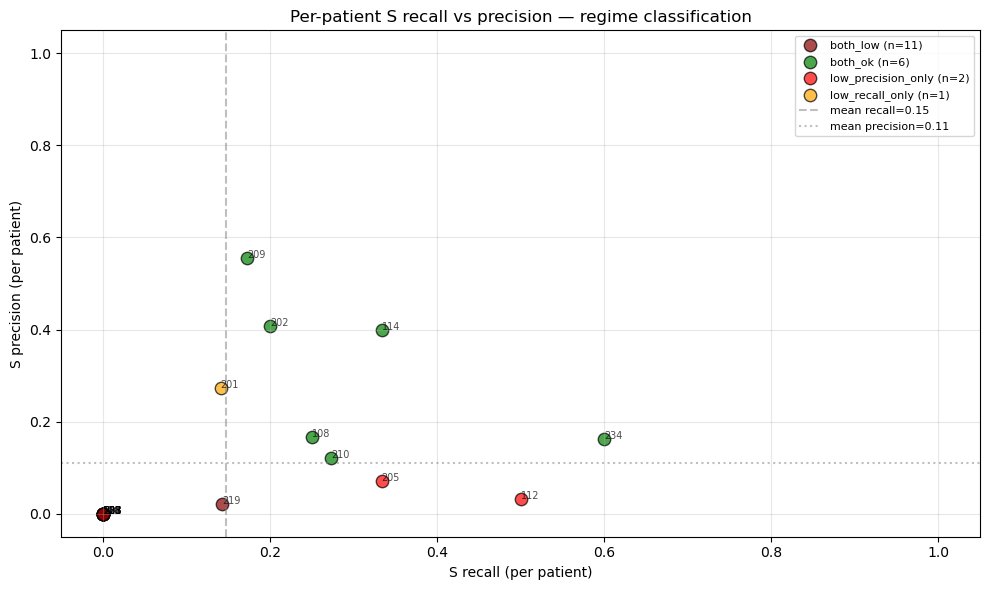

Saved: outputs_v9/diag1_per_patient_S.png


In [14]:
# ── Visualize: per-patient recall vs precision scatter ──────────────────────
fig, ax = plt.subplots(figsize=(10, 6))
df_plot = df_pp_S[df_pp_S['n_true_S'] > 0].copy()
colors = {'both_ok': 'green', 'low_recall_only': 'orange',
          'low_precision_only': 'red', 'both_low': 'darkred', 'no_target': 'gray'}
for regime, sub in df_plot.groupby('regime'):
    ax.scatter(sub['S_recall'], sub['S_precision'],
               label=f'{regime} (n={len(sub)})', c=colors.get(regime, 'blue'),
               s=80, alpha=0.7, edgecolors='black')
ax.axvline(regime_summary_S['mean_recall'], color='gray', linestyle='--', alpha=0.5,
           label=f"mean recall={regime_summary_S['mean_recall']:.2f}")
ax.axhline(regime_summary_S['mean_precision'], color='gray', linestyle=':', alpha=0.5,
           label=f"mean precision={regime_summary_S['mean_precision']:.2f}")
for _, row in df_plot.iterrows():
    ax.annotate(row['record'].replace('mitbih_', ''), (row['S_recall'], row['S_precision']),
                fontsize=7, alpha=0.7)
ax.set_xlabel('S recall (per patient)')
ax.set_ylabel('S precision (per patient)')
ax.set_title('Per-patient S recall vs precision — regime classification')
ax.legend(loc='best', fontsize=8)
ax.set_xlim(-0.05, 1.05); ax.set_ylim(-0.05, 1.05)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(f'{OUTPUTS_DIR}/diag1_per_patient_S.png', dpi=120, bbox_inches='tight')
plt.show()
print(f"Saved: {OUTPUTS_DIR}/diag1_per_patient_S.png")


## Diagnostic 2 — Repartition to 3-fold internal CV + INCART distribution shift check

**The 4-patient val problem.** v8.7 used 4 val records (105, 124, 214, 220), giving only ~47 S val examples. Training logs show the SV head's per-epoch val metrics bouncing wildly (epoch 1: S recall 1.0 / precision 0.06; epoch 2: S recall 0.0). With 4 source patients:

- Patient-level bootstrap has 2^4 − 2 = 14 unique non-trivial subsets; with-replacement resampling has *less* effective diversity than that.
- The bootstrap cannot give a meaningful CI from 4 data points — it gives a slightly smoothed empirical distribution over a handful of subsets, which will almost certainly be wide.
- The bootstrap is a sanity check, not a fix. **If the bootstrap is unstable, the answer is more patients, not a better threshold selection method.**

**Fix:** repartition the 18 MIT-BIH train records into 3 internal folds (~6 patients per fold). For each fold, use 2 folds as internal-train (12 patients) and 1 as internal-val (6 patients). The test set (24 records) is *never touched* — it remains the held-out final-evaluation set, as in v8.7.

**INCART distribution-shift check.** INCART is the natural fallback for calibration if the 3-fold still proves unstable, but it's only valid if INCART's gate/V/S probability distributions are similar enough to MIT-BIH-val's. We check this **regardless of whether the fallback is needed** — it's cheap and gates the fallback.

In [15]:
# ── Build 3-fold partition of the 18 train records ───────────────────────────
train_records_all = MITBIH_TRAIN_RECORDS.copy()
print(f"Train records for 3-fold split ({len(train_records_all)}): {train_records_all}")

# Stratified-by-S-count split: sort by S beat count (desc) and deal round-robin
# so each fold gets a mix of S-heavy and S-light records.
rec_s_counts = {}
for r in train_records_all:
    rec_tag = f'mitbih_{r}'
    mask = recs_train == rec_tag
    rec_s_counts[r] = int(np.sum(y_train_raw[mask] == 'S'))
sorted_recs = sorted(train_records_all, key=lambda r: -rec_s_counts[r])
print("\nS beat counts per train record:")
for r in sorted_recs:
    print(f"  mitbih_{r}: {rec_s_counts[r]} S beats")

folds = {0: [], 1: [], 2: []}
for i, r in enumerate(sorted_recs):
    folds[i % 3].append(r)
for k in folds:
    folds[k].sort()
    print(f"\nFold {k} ({len(folds[k])} records): {folds[k]}")
    fold_s = sum(rec_s_counts[r] for r in folds[k])
    print(f"  Total S beats in fold: {fold_s}")

# Save fold assignment
fold_assignment = {f'mitbih_{r}': k for k, recs in folds.items() for r in recs}
with open(f'{OUTPUTS_DIR}/fold_assignment.json', 'w') as f:
    json.dump({'folds': folds, 'fold_assignment': fold_assignment,
               'rec_s_counts': {str(k): v for k, v in rec_s_counts.items()}}, f, indent=2)

# Build per-fold index masks on the train arrays
fold_masks = {}
for k in range(3):
    fold_recs = {f'mitbih_{r}' for r in folds[k]}
    fold_masks[k] = np.isin(recs_train, list(fold_recs))
    print(f"  Fold {k}: {fold_masks[k].sum()} beats, classes={Counter(y_train_raw[fold_masks[k]])}")

# For threshold sweeps, we'll use each fold as internal-val with the other two as
# internal-train. For the baseline diagnostics (Steps 1, 3, 4, 5) we use the
# ORIGINAL v8.7 val (4 records) so we're comparing against a known baseline.
# The 3-fold is for Step 3's stability check.


Train records for 3-fold split (18): [100, 102, 103, 104, 107, 111, 113, 117, 121, 122, 123, 200, 212, 213, 215, 222, 230, 232]

S beat counts per train record:
  mitbih_232: 1382 S beats
  mitbih_222: 209 S beats
  mitbih_100: 33 S beats
  mitbih_200: 30 S beats
  mitbih_213: 28 S beats
  mitbih_113: 6 S beats
  mitbih_215: 3 S beats
  mitbih_103: 2 S beats
  mitbih_117: 1 S beats
  mitbih_121: 1 S beats
  mitbih_102: 0 S beats
  mitbih_104: 0 S beats
  mitbih_107: 0 S beats
  mitbih_111: 0 S beats
  mitbih_122: 0 S beats
  mitbih_123: 0 S beats
  mitbih_212: 0 S beats
  mitbih_230: 0 S beats

Fold 0 (6 records): [107, 121, 123, 200, 215, 232]
  Total S beats in fold: 1416

Fold 1 (6 records): [102, 103, 111, 212, 213, 222]
  Total S beats in fold: 239

Fold 2 (6 records): [100, 104, 113, 117, 122, 230]
  Total S beats in fold: 40
  Fold 0: 11182 beats, classes=Counter({'N': 8710, 'S': 1416, 'V': 1056})
  Fold 1: 12790 beats, classes=Counter({'N': 11964, 'V': 587, 'S': 239})
  Fold 2:

Loading INCART for distribution-shift check...

Distribution shift (Wasserstein distance, INCART vs MIT-BIH val):
  Gate probs     : 0.2435
  V-head (routed): 0.27569408743823326
  S-head (routed): 0.32763048885864904


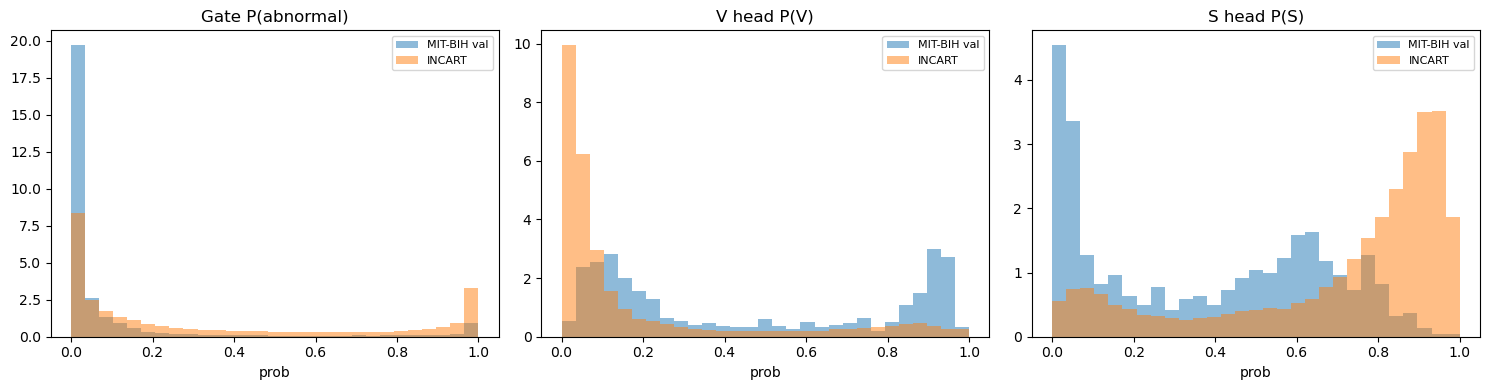

Saved: outputs_v9/diag2_dist_shift.png

INCART eligible as calibration fallback (all Wasserstein < 0.15)? False
  ✓ metrics saved: outputs_v9/metrics/metrics_diag2_repartition_distshift.json


In [16]:
# ── INCART-vs-MIT-BIH-val distribution shift check ──────────────────────────
# Run both gate and SV heads on INCART, compare probability distributions to
# MIT-BIH val. If they're shifted, calibrating thresholds on INCART introduces
# a domain-mismatch you'd be trading the small-sample problem for.

if INCART_AVAILABLE:
    print("Loading INCART for distribution-shift check...")
    inc_beats, inc_rr, inc_labels, inc_recs = load_records(
        INCART_PATH, INCART_RECORDS, 'incart', two_channel=True
    )
    X_rr_incart_norm = (inc_rr - RR_MEAN) / RR_STD
    y_incart = le.transform(inc_labels)

    gate_probs_inc   = gate_model.predict([inc_beats, X_rr_incart_norm], batch_size=256, verbose=0).flatten()
    gate_probs_mbval = gate_model.predict([X_val, X_rr_val_norm], batch_size=256, verbose=0).flatten()

    # Run SV head on gate-routed INCART and MIT-BIH val
    routed_inc_mask   = gate_probs_inc   > BASELINE_GATE_THR_FOR_DIAG
    routed_mbval_mask = gate_probs_mbval > BASELINE_GATE_THR_FOR_DIAG

    if routed_inc_mask.any():
        v_prob_inc, s_prob_inc = sv_model.predict(
            [inc_beats[routed_inc_mask], X_rr_incart_norm[routed_inc_mask]],
            batch_size=256, verbose=0)
        v_prob_inc = v_prob_inc.flatten(); s_prob_inc = s_prob_inc.flatten()
    else:
        v_prob_inc = np.array([]); s_prob_inc = np.array([])

    if routed_mbval_mask.any():
        v_prob_mbv, s_prob_mbv = sv_model.predict(
            [X_val[routed_mbval_mask], X_rr_val_norm[routed_mbval_mask]],
            batch_size=256, verbose=0)
        v_prob_mbv = v_prob_mbv.flatten(); s_prob_mbv = s_prob_mbv.flatten()
    else:
        v_prob_mbv = np.array([]); s_prob_mbv = np.array([])

    # Wasserstein distance (Earth Mover's Distance) — robust for empirical distributions
    shift_results = {
        'gate': float(wasserstein_distance(gate_probs_inc, gate_probs_mbval)),
        'v_head_routed': float(wasserstein_distance(v_prob_inc, v_prob_mbv)) if len(v_prob_inc)>0 and len(v_prob_mbv)>0 else None,
        's_head_routed': float(wasserstein_distance(s_prob_inc, s_prob_mbv)) if len(s_prob_inc)>0 and len(s_prob_mbv)>0 else None,
        'n_incart_beats': len(inc_beats),
        'n_incart_routed': int(routed_inc_mask.sum()),
        'n_mbval_beats': len(X_val),
        'n_mbval_routed': int(routed_mbval_mask.sum()),
    }
    print(f"\nDistribution shift (Wasserstein distance, INCART vs MIT-BIH val):")
    print(f"  Gate probs     : {shift_results['gate']:.4f}")
    print(f"  V-head (routed): {shift_results['v_head_routed']}")
    print(f"  S-head (routed): {shift_results['s_head_routed']}")

    # Plot
    fig, axes = plt.subplots(1, 3, figsize=(15, 4))
    for ax, (inc, mbv, title) in zip(axes, [
        (gate_probs_inc, gate_probs_mbval, 'Gate P(abnormal)'),
        (v_prob_inc, v_prob_mbv, 'V head P(V)'),
        (s_prob_inc, s_prob_mbv, 'S head P(S)'),
    ]):
        if len(inc) > 0 and len(mbv) > 0:
            bins = np.linspace(0, 1, 30)
            ax.hist(mbv, bins=bins, alpha=0.5, label='MIT-BIH val', density=True)
            ax.hist(inc, bins=bins, alpha=0.5, label='INCART', density=True)
            ax.set_title(title); ax.legend(fontsize=8); ax.set_xlabel('prob')
    plt.tight_layout()
    plt.savefig(f'{OUTPUTS_DIR}/diag2_dist_shift.png', dpi=120, bbox_inches='tight')
    plt.show()
    print(f"Saved: {OUTPUTS_DIR}/diag2_dist_shift.png")

    # Heuristic: if Wasserstein > 0.15 on any head, fallback to INCART-as-calibration
    # would reintroduce meaningful domain shift — flag it.
    shift_threshold = 0.15
    incart_eligible_for_calibration = all(
        v is None or v < shift_threshold for v in
        [shift_results['gate'], shift_results['v_head_routed'], shift_results['s_head_routed']]
    )
    print(f"\nINCART eligible as calibration fallback (all Wasserstein < {shift_threshold})? "
          f"{incart_eligible_for_calibration}")

    save_run_metrics('diag2_repartition_distshift', stage='diagnostic_2_repartition',
                     distribution_shift=shift_results,
                     extra={'folds': folds, 'incart_eligible_for_calibration': incart_eligible_for_calibration})
else:
    print("INCART not available — skipping distribution-shift check. "
          "INCART-as-calibration fallback is NOT available if 3-fold proves unstable.")
    incart_eligible_for_calibration = False
    shift_results = None


## Diagnostic 3 — Joint `(gate_thr, V_thr, S_thr)` sweep with patient-level bootstrap

**Replaces v8.7's per-head sequential V-then-S sweep.** Sequential selection cannot escape local optima introduced by V/S interaction: a V threshold chosen without considering S routing can route too many S beats to "N" via the V-claimed → not-S-claimed path.

**Objective:** end-of-cascade Macro F1, not gate-stage or per-head metrics.

**Joint sweep grid:** 25 gate × 17 V × 17 S = 7,225 combinations per fold.

**Stability check:** patient-level bootstrap with replacement, 50 resamples per fold. With ~6 source patients per fold this is a sanity check, not a clean CI — wide spread means "val is too small to support threshold selection at all," and the answer is more patients (or accept INCART-as-calibration if Diagnostic 2 cleared it), not a different selection method.

**Cross-fold aggregation:** report the chosen triple per fold. If all three folds pick similar triples, the choice is robust. If they disagree, the cascade's reported test F1 is sensitive to which val patients you happened to draw.

In [17]:
def joint_threshold_sweep(gate_probs, v_probs, s_probs, y_true,
                          n_idx, s_idx, v_idx,
                          gate_thrs, v_thrs, s_thrs):
    """Vectorized joint threshold sweep. Returns DataFrame with one row per
    (gate_thr, v_thr, s_thr) combination, with macro_f1 and per-class metrics.

    For efficiency, v_probs and s_probs are expected to be the SAME length as
    gate_probs and y_true — fill with 0.0 for non-routed beats (we never look
    at them anyway because routed mask is applied first).
    """
    rows = []
    # Precompute y_true as int8 for speed
    y_t = y_true.astype(np.int8)
    for g_thr in gate_thrs:
        routed = gate_probs > g_thr
        n_routed = int(routed.sum())
        if n_routed == 0:
            # All beats routed to N — degenerate case
            for v_thr in v_thrs:
                for s_thr in s_thrs:
                    # macro F1 when everything is predicted N
                    tp_n = int(np.sum(y_t == n_idx))
                    cm_n = tp_n / max(len(y_t), 1)
                    rec_n = cm_n; prec_n = cm_n  # all pred=N, only N is correct
                    f1_n = 2 * prec_n * rec_n / max(prec_n + rec_n, 1e-7)
                    rows.append({'gate_thr': float(g_thr), 'v_thr': float(v_thr),
                                  's_thr': float(s_thr), 'macro_f1': float((f1_n+0+0)/3),
                                  's_recall': 0.0, 's_precision': 0.0,
                                  'v_recall': 0.0, 'n_precision': prec_n})
            continue

        for v_thr in v_thrs:
            v_claim = routed & (v_probs > v_thr)
            for s_thr in s_thrs:
                s_claim = routed & (~v_claim) & (s_probs > s_thr)
                # Build y_pred as int8
                y_p = np.full_like(y_t, n_idx)
                y_p[v_claim] = v_idx
                y_p[s_claim] = s_idx

                # Confusion matrix via bincount on y_t * 3 + y_p (vectorized)
                flat = (y_t * 3 + y_p).astype(np.int32)
                counts = np.bincount(flat, minlength=9)
                cm = counts.reshape(3, 3)

                # Per-class F1
                f1s = []
                recalls = []; precisions = []
                for i in range(3):
                    tp = int(cm[i, i])
                    fn = int(cm[i, :].sum() - tp)
                    fp = int(cm[:, i].sum() - tp)
                    rec = tp / max(tp + fn, 1)
                    prec = tp / max(tp + fp, 1)
                    f1 = 2 * prec * rec / max(prec + rec, 1e-7)
                    f1s.append(f1); recalls.append(rec); precisions.append(prec)

                rows.append({
                    'gate_thr': float(g_thr), 'v_thr': float(v_thr), 's_thr': float(s_thr),
                    'macro_f1': float(np.mean(f1s)),
                    's_recall': recalls[s_idx], 's_precision': precisions[s_idx],
                    'v_recall': recalls[v_idx], 'n_precision': precisions[n_idx],
                })
    return pd.DataFrame(rows)


def patient_level_bootstrap_sweep(gate_probs, v_probs, s_probs, y_true, recs,
                                   n_idx, s_idx, v_idx,
                                   gate_thrs, v_thrs, s_thrs,
                                   n_bootstrap=50, seed=42):
    """Run joint sweep on patient-level bootstrap resamples.

    Returns DataFrame of chosen (gate_thr, v_thr, s_thr, macro_f1) per resample.

    NOTE: with N source patients, patient-level bootstrap with replacement has
    extremely limited effective diversity (for N=6, only ~50 unique multisets
    of size 6 dominate the resampling distribution). This is a sanity check,
    not a clean CI. Report the spread honestly.
    """
    rng = np.random.default_rng(seed)
    unique_patients = sorted(set(recs))
    n_patients = len(unique_patients)
    print(f"  Bootstrap: {n_patients} source patients, {n_bootstrap} resamples")
    if n_patients < 8:
        print(f"  WARNING: only {n_patients} patients — bootstrap spread will be wide")

    # Pre-pad v_probs and s_probs with zeros so they align with gate_probs/y_true
    # (non-routed beats will never be looked at anyway)
    if len(v_probs) != len(gate_probs):
        v_full = np.zeros_like(gate_probs)
        v_full[:len(v_probs)] = v_probs
    else:
        v_full = v_probs
    if len(s_probs) != len(gate_probs):
        s_full = np.zeros_like(gate_probs)
        s_full[:len(s_probs)] = s_probs
    else:
        s_full = s_probs

    chosen = []
    for b in range(n_bootstrap):
        sampled = rng.choice(unique_patients, size=n_patients, replace=True)
        idx = np.concatenate([np.where(recs == p)[0] for p in sampled])
        df = joint_threshold_sweep(
            gate_probs[idx], v_full[idx], s_full[idx], y_true[idx],
            n_idx, s_idx, v_idx, gate_thrs, v_thrs, s_thrs,
        )
        best = df.loc[df['macro_f1'].idxmax()]
        chosen.append({
            'bootstrap_idx': b,
            'gate_thr': float(best['gate_thr']),
            'v_thr': float(best['v_thr']),
            's_thr': float(best['s_thr']),
            'macro_f1': float(best['macro_f1']),
        })
    return pd.DataFrame(chosen)


print("Joint sweep + bootstrap functions defined.")
print(f"Sweep grid: {len(GATE_THRS)}×{len(V_THRS)}×{len(S_THRS)} = "
      f"{len(GATE_THRS)*len(V_THRS)*len(S_THRS)} combinations per evaluation")


Joint sweep + bootstrap functions defined.
Sweep grid: 25×17×17 = 7225 combinations per evaluation


In [18]:
# ── Run joint sweep on v8.7 val (4 records) — the baseline ───────────────────
print("=" * 80)
print("Joint sweep on v8.7 val (4 records, ~47 S beats) — baseline")
print("=" * 80)

gate_probs_val = gate_model.predict([X_val, X_rr_val_norm], batch_size=256, verbose=0).flatten()
routed_val_mask = gate_probs_val > 0.0  # all beats — sweep gate_thr internally
v_prob_val_full = np.zeros_like(gate_probs_val)
s_prob_val_full = np.zeros_like(gate_probs_val)
v_prob_tmp, s_prob_tmp = sv_model.predict([X_val, X_rr_val_norm], batch_size=256, verbose=0)
v_prob_val_full = v_prob_tmp.flatten()
s_prob_val_full = s_prob_tmp.flatten()

df_sweep_val = joint_threshold_sweep(
    gate_probs_val, v_prob_val_full, s_prob_val_full, y_val,
    n_idx, s_idx, v_idx, GATE_THRS, V_THRS, S_THRS,
)
best_val = df_sweep_val.loc[df_sweep_val['macro_f1'].idxmax()]
print(f"\nBest triple on v8.7 val: "
      f"gate={best_val['gate_thr']:.3f}, V={best_val['v_thr']:.2f}, S={best_val['s_thr']:.2f} "
      f"→ macro_f1={best_val['macro_f1']:.4f}")
print(f"  S recall={best_val['s_recall']:.3f}, S precision={best_val['s_precision']:.3f}")
print(f"  V recall={best_val['v_recall']:.3f}, N precision={best_val['n_precision']:.3f}")

# Top 10 to see how flat the optimum is
print("\nTop 10 triples by macro_f1:")
print(df_sweep_val.nlargest(10, 'macro_f1')[
    ['gate_thr','v_thr','s_thr','macro_f1','s_recall','s_precision','v_recall','n_precision']
].to_string(index=False, float_format='%.3f'))

# Bootstrap stability on v8.7 val
print("\nPatient-level bootstrap on v8.7 val (4 patients)...")
df_boot_v87 = patient_level_bootstrap_sweep(
    gate_probs_val, v_prob_val_full, s_prob_val_full, y_val, recs_val,
    n_idx, s_idx, v_idx, GATE_THRS, V_THRS, S_THRS,
    n_bootstrap=N_BOOTSTRAP, seed=SEED,
)
print(f"\nBootstrap spread (v8.7 val, 4 patients):")
print(f"  gate_thr: mean={df_boot_v87['gate_thr'].mean():.3f}, "
      f"std={df_boot_v87['gate_thr'].std():.3f}, "
      f"min={df_boot_v87['gate_thr'].min():.3f}, max={df_boot_v87['gate_thr'].max():.3f}")
print(f"  v_thr   : mean={df_boot_v87['v_thr'].mean():.3f}, "
      f"std={df_boot_v87['v_thr'].std():.3f}")
print(f"  s_thr   : mean={df_boot_v87['s_thr'].mean():.3f}, "
      f"std={df_boot_v87['s_thr'].std():.3f}")
print(f"  macro_f1: mean={df_boot_v87['macro_f1'].mean():.4f}, "
      f"std={df_boot_v87['macro_f1'].std():.4f}")


Joint sweep on v8.7 val (4 records, ~47 S beats) — baseline

Best triple on v8.7 val: gate=0.700, V=0.15, S=0.60 → macro_f1=0.6268
  S recall=0.192, S precision=0.197
  V recall=0.729, N precision=0.981

Top 10 triples by macro_f1:
 gate_thr  v_thr  s_thr  macro_f1  s_recall  s_precision  v_recall  n_precision
    0.700  0.150  0.600     0.627     0.192        0.197     0.729        0.981
    0.675  0.150  0.600     0.624     0.192        0.186     0.734        0.981
    0.700  0.200  0.550     0.624     0.224        0.181     0.680        0.981
    0.700  0.150  0.650     0.624     0.160        0.220     0.729        0.979
    0.700  0.200  0.500     0.623     0.232        0.171     0.680        0.982
    0.700  0.150  0.550     0.622     0.192        0.171     0.729        0.982
    0.700  0.150  0.100     0.622     0.192        0.170     0.729        0.982
    0.700  0.150  0.150     0.622     0.192        0.170     0.729        0.982
    0.700  0.150  0.200     0.622     0.192     

In [19]:
# ── Run joint sweep on each of the 3 internal folds ──────────────────────────
print("=" * 80)
print("Joint sweep on 3 internal folds (6 patients each)")
print("=" * 80)

fold_sweep_results = {}
for k in range(3):
    val_mask_k = fold_masks[k]
    train_mask_k = ~val_mask_k & np.isin(recs_train, [f'mitbih_{r}' for r in
                                                       MITBIH_TRAIN_RECORDS])

    X_val_k = X_train[val_mask_k]
    X_rr_val_k = X_rr_train_norm[val_mask_k]
    y_val_k = y_train[val_mask_k]
    recs_val_k = recs_train[val_mask_k]

    print(f"\n--- Fold {k} (val: {sorted(set(recs_val_k))}, "
          f"{len(X_val_k)} beats, classes={Counter(y_train_raw[val_mask_k])}) ---")

    gate_probs_k = gate_model.predict([X_val_k, X_rr_val_k], batch_size=256, verbose=0).flatten()
    v_prob_k, s_prob_k = sv_model.predict([X_val_k, X_rr_val_k], batch_size=256, verbose=0)
    v_prob_k = v_prob_k.flatten(); s_prob_k = s_prob_k.flatten()

    df_sweep_k = joint_threshold_sweep(
        gate_probs_k, v_prob_k, s_prob_k, y_val_k,
        n_idx, s_idx, v_idx, GATE_THRS, V_THRS, S_THRS,
    )
    best_k = df_sweep_k.loc[df_sweep_k['macro_f1'].idxmax()]
    print(f"  Best triple: gate={best_k['gate_thr']:.3f}, "
          f"V={best_k['v_thr']:.2f}, S={best_k['s_thr']:.2f} "
          f"→ macro_f1={best_k['macro_f1']:.4f}")

    df_boot_k = patient_level_bootstrap_sweep(
        gate_probs_k, v_prob_k, s_prob_k, y_val_k, recs_val_k,
        n_idx, s_idx, v_idx, GATE_THRS, V_THRS, S_THRS,
        n_bootstrap=N_BOOTSTRAP, seed=SEED + k,
    )
    print(f"  Bootstrap spread: gate std={df_boot_k['gate_thr'].std():.3f}, "
          f"v_thr std={df_boot_k['v_thr'].std():.3f}, "
          f"s_thr std={df_boot_k['s_thr'].std():.3f}")

    fold_sweep_results[k] = {
        'best_triple': best_k.to_dict(),
        'bootstrap_summary': {
            'gate_thr_mean': float(df_boot_k['gate_thr'].mean()),
            'gate_thr_std': float(df_boot_k['gate_thr'].std()),
            'v_thr_mean': float(df_boot_k['v_thr'].mean()),
            'v_thr_std': float(df_boot_k['v_thr'].std()),
            's_thr_mean': float(df_boot_k['s_thr'].mean()),
            's_thr_std': float(df_boot_k['s_thr'].std()),
            'macro_f1_mean': float(df_boot_k['macro_f1'].mean()),
            'macro_f1_std': float(df_boot_k['macro_f1'].std()),
        },
        'n_val_patients': len(set(recs_val_k)),
        'n_val_beats': len(X_val_k),
        'n_val_S': int(np.sum(y_train_raw[val_mask_k] == 'S')),
    }

# Cross-fold comparison
print("\n" + "=" * 80)
print("CROSS-FOLD STABILITY")
print("=" * 80)
print(f"{'Fold':<6} {'gate_thr':<10} {'v_thr':<8} {'s_thr':<8} {'macro_f1':<10} "
      f"{'gate_std':<10} {'n_patients':<11} {'n_S':<5}")
for k in range(3):
    r = fold_sweep_results[k]
    b = r['best_triple']
    bs = r['bootstrap_summary']
    print(f"{k:<6} {b['gate_thr']:<10.3f} {b['v_thr']:<8.2f} {b['s_thr']:<8.2f} "
          f"{b['macro_f1']:<10.4f} {bs['gate_thr_std']:<10.3f} "
          f"{r['n_val_patients']:<11} {r['n_val_S']:<5}")

# Aggregate: median triple across folds (more robust than mean for thresholds)
gate_thrs_chosen = [fold_sweep_results[k]['best_triple']['gate_thr'] for k in range(3)]
v_thrs_chosen    = [fold_sweep_results[k]['best_triple']['v_thr'] for k in range(3)]
s_thrs_chosen    = [fold_sweep_results[k]['best_triple']['s_thr'] for k in range(3)]
JOINT_GATE_THR = float(np.median(gate_thrs_chosen))
JOINT_V_THR    = float(np.median(v_thrs_chosen))
JOINT_S_THR    = float(np.median(s_thrs_chosen))
print(f"\nMedian triple across folds: gate={JOINT_GATE_THR:.3f}, "
      f"V={JOINT_V_THR:.2f}, S={JOINT_S_THR:.2f}")
print(f"Spread (max-min): gate={max(gate_thrs_chosen)-min(gate_thrs_chosen):.3f}, "
      f"V={max(v_thrs_chosen)-min(v_thrs_chosen):.2f}, "
      f"S={max(s_thrs_chosen)-min(s_thrs_chosen):.2f}")

stability_warning = (max(gate_thrs_chosen) - min(gate_thrs_chosen) > 0.20 or
                      max(v_thrs_chosen) - min(v_thrs_chosen) > 0.20 or
                      max(s_thrs_chosen) - min(s_thrs_chosen) > 0.20)
if stability_warning:
    print("  ⚠ Thresholds unstable across folds — Step 6's retrain loop should "
          "use the median triple but report the spread.")
    if incart_eligible_for_calibration:
        print("  ⚠ INCART is eligible as a calibration fallback (Diagnostic 2 cleared it).")
    else:
        print("  ⚠ INCART is NOT eligible — must proceed with 3-fold median despite instability.")

save_run_metrics('diag3_joint_sweep', stage='diagnostic_3_joint_sweep',
                 thresholds={'joint_gate_thr': JOINT_GATE_THR,
                             'joint_v_thr': JOINT_V_THR,
                             'joint_s_thr': JOINT_S_THR},
                 bootstrap_summary={
                     'v87_val_4pat': {
                         'gate_thr_std': float(df_boot_v87['gate_thr'].std()),
                         'v_thr_std': float(df_boot_v87['v_thr'].std()),
                         's_thr_std': float(df_boot_v87['s_thr'].std()),
                         'macro_f1_std': float(df_boot_v87['macro_f1'].std()),
                     },
                     'folds_3_6pat': {str(k): fold_sweep_results[k]['bootstrap_summary']
                                       for k in range(3)},
                 },
                 extra={'fold_best_triples': {str(k): fold_sweep_results[k]['best_triple']
                                              for k in range(3)},
                        'stability_warning': stability_warning,
                        'incart_eligible_for_calibration': incart_eligible_for_calibration})


Joint sweep on 3 internal folds (6 patients each)

--- Fold 0 (val: ['mitbih_107', 'mitbih_121', 'mitbih_123', 'mitbih_200', 'mitbih_215', 'mitbih_232'], 11182 beats, classes=Counter({'N': 8710, 'S': 1416, 'V': 1056})) ---
  Best triple: gate=0.600, V=0.10, S=0.85 → macro_f1=0.9866
  Bootstrap: 6 source patients, 50 resamples
  Bootstrap spread: gate std=0.173, v_thr std=0.115, s_thr std=0.304

--- Fold 1 (val: ['mitbih_102', 'mitbih_103', 'mitbih_111', 'mitbih_212', 'mitbih_213', 'mitbih_222'], 12790 beats, classes=Counter({'N': 11964, 'V': 587, 'S': 239})) ---
  Best triple: gate=0.375, V=0.20, S=0.70 → macro_f1=0.9003
  Bootstrap: 6 source patients, 50 resamples
  Bootstrap spread: gate std=0.142, v_thr std=0.115, s_thr std=0.219

--- Fold 2 (val: ['mitbih_100', 'mitbih_104', 'mitbih_113', 'mitbih_117', 'mitbih_122', 'mitbih_230'], 10495 beats, classes=Counter({'N': 10451, 'S': 40, 'V': 4})) ---
  Best triple: gate=0.700, V=0.20, S=0.55 → macro_f1=0.9870
  Bootstrap: 6 source patien

'outputs_v9/metrics/metrics_diag3_joint_sweep.json'

## Diagnostic 4 — Blinded inspection of 50–70 misclassified S beats

**Goal:** categorize S failures as one of:
- **Underfitting** — the model could learn this with more capacity/data/epochs
- **Ambiguous** — genuinely hard S vs N boundary case
- **Label noise** — the beat is clearly mislabeled
- **Clipped context** — the 130-sample window is missing the compensatory pause or P-wave needed to disambiguate

This categorization gates downstream decisions:
- Hard-S mining helps only if most errors are *underfitting*
- Focal loss helps only if there isn't heavy *label noise*
- Window re-extraction helps only if many errors are *clipped context*

**Blinding protocol:** to prevent the categorizer (you) from inheriting the model's own biases, we hide the source record, model confidence, and predicted class. Each beat is shown with only its ECG morphology and RR features. After categorization, we re-attach the metadata and analyze.

In [21]:
# ── Identify hardest S errors ─────────────────────────────────────────────────
# "Hardest" = beats the model is most confidently wrong about, OR where true S
# was routed to N (gate miss). Sample a mix:
#   - 20 gate-missed S (gate_prob < thr, true=S)
#   - 30 SV-misclassified S (gate routed, SV predicted V or N)
#   - 10 lowest-confidence correct S predictions (hardest "right" answers)
os.makedirs(f'{OUTPUTS_DIR}/inspection/beats', exist_ok=True)
gate_probs_test_arr = gate_probs_test
v_prob_test_full = np.zeros_like(gate_probs_test_arr)
s_prob_test_full = np.zeros_like(gate_probs_test_arr)
v_prob_tmp, s_prob_tmp = sv_model.predict([X_test, X_rr_test_norm], batch_size=256, verbose=0)
v_prob_test_full = v_prob_tmp.flatten()
s_prob_test_full = s_prob_tmp.flatten()

# Recompute y_pred with the JOINT sweep triple (more principled than v8.7 baseline)
y_pred_joint = np.full(len(y_test), n_idx, dtype=int)
gate_pass = gate_probs_test_arr > JOINT_GATE_THR
if gate_pass.any():
    routed_pred = np.full(gate_pass.sum(), n_idx, dtype=int)
    v_fire = v_prob_test_full[gate_pass] > JOINT_V_THR
    routed_pred[v_fire] = v_idx
    s_fire = (~v_fire) & (s_prob_test_full[gate_pass] > JOINT_S_THR)
    routed_pred[s_fire] = s_idx
    y_pred_joint[gate_pass] = routed_pred

# Find S errors
s_mask = y_test == s_idx
s_errors_mask = s_mask & (y_pred_joint != s_idx)
s_gate_miss_mask = s_mask & (~gate_pass)  # true S, gate routed to N
s_sv_miss_mask = s_mask & gate_pass & (y_pred_joint != s_idx)  # true S, gate routed, SV got it wrong
s_correct_mask = s_mask & (y_pred_joint == s_idx)

print(f"True S beats in test     : {int(s_mask.sum())}")
print(f"  Gate-missed (routed N) : {int(s_gate_miss_mask.sum())}")
print(f"  SV-misclassified       : {int(s_sv_miss_mask.sum())}")
print(f"  Correctly classified   : {int(s_correct_mask.sum())}")

# Sample
rng = np.random.default_rng(SEED)
n_gate_miss = min(20, int(s_gate_miss_mask.sum()))
n_sv_miss   = min(30, int(s_sv_miss_mask.sum()))
n_correct   = min(10, int(s_correct_mask.sum()))

idx_gate_miss = rng.choice(np.where(s_gate_miss_mask)[0], size=n_gate_miss, replace=False)
idx_sv_miss   = rng.choice(np.where(s_sv_miss_mask)[0], size=n_sv_miss, replace=False)
# For correct, pick the ones with LOWEST model confidence on the S head
s_correct_idx = np.where(s_correct_mask)[0]
s_correct_conf = s_prob_test_full[s_correct_idx]
idx_correct = s_correct_idx[np.argsort(s_correct_conf)[:n_correct]]

inspection_idx = np.concatenate([idx_gate_miss, idx_sv_miss, idx_correct])
inspection_idx = rng.permutation(inspection_idx)  # shuffle so categorizer can't infer category from order

print(f"\nInspection sample: {len(inspection_idx)} beats")
print(f"  {n_gate_miss} gate-missed, {n_sv_miss} SV-misclassified, {n_correct} low-confidence correct (SHUFFLED)")

# ── Build blinded inspection package ─────────────────────────────────────────
# Each beat gets a blinded ID (hash). Metadata is stored separately and only
# re-attached after the categorization CSV is filled in.
inspection_rows = []
for i, idx in enumerate(inspection_idx):
    beat = X_test[idx]  # (130, 2)
    rr = X_rr_test[idx]  # raw (un-normalized for human readability)
    blinded_id = hashlib.sha256(f"{idx}_{recs_test[idx]}_{y_test[idx]}".encode()).hexdigest()[:12]

    # Save plot
    fig, axes = plt.subplots(1, 2, figsize=(10, 3))
    t_ms = np.arange(WINDOW_LEN) / TARGET_FS * 1000
    axes[0].plot(t_ms, beat[:, 0], 'b-', linewidth=0.8)
    axes[0].set_title(f'Blinded ID: {blinded_id} (lead 1)')
    axes[0].set_xlabel('ms'); axes[0].grid(alpha=0.3)
    axes[1].plot(t_ms, beat[:, 1], 'r-', linewidth=0.8)
    axes[1].set_title(f'(lead 2)')
    axes[1].set_xlabel('ms'); axes[1].grid(alpha=0.3)
    plt.tight_layout()
    plt.savefig(f'{OUTPUTS_DIR}/inspection/beats/{blinded_id}.png', dpi=100, bbox_inches='tight')
    plt.close()

    inspection_rows.append({
        'blinded_id': blinded_id,
        'rr_prev_sec': float(rr[0]),
        'rr_next_sec': float(rr[1]),
        'rr_ratio': float(rr[2]),
        'rr_mean_5_sec': float(rr[3]),
        'rr_std_5_sec': float(rr[4]),
        'compensatory_ratio': float(rr[5]),
        'prematurity_index': float(rr[6]),
        'category': '',  # TO FILL IN: underfitting / ambiguous / label_noise / clipped_context
        'notes': '',
        # Hidden metadata (do NOT look at these when categorizing):
        '_hidden_idx': int(idx),
        '_hidden_record': recs_test[idx],
        '_hidden_true_label': le.classes_[y_test[idx]],
        '_hidden_pred_label': le.classes_[y_pred_joint[idx]],
        '_hidden_gate_prob': float(gate_probs_test_arr[idx]),
        '_hidden_v_prob': float(v_prob_test_full[idx]),
        '_hidden_s_prob': float(s_prob_test_full[idx]),
    })

os.makedirs(f'{OUTPUTS_DIR}/inspection/beats', exist_ok=True)
df_inspect = pd.DataFrame(inspection_rows)
# Save blinded version (no _hidden columns)
blinded_cols = [c for c in df_inspect.columns if not c.startswith('_hidden')]
df_inspect[blinded_cols].to_csv(f'{OUTPUTS_DIR}/inspection/blinded_for_categorization.csv', index=False)
# Save full version (with hidden metadata, for re-attachment after categorization)
df_inspect.to_csv(f'{OUTPUTS_DIR}/inspection/full_with_metadata.csv', index=False)

print(f"\nBlinded inspection package saved:")
print(f"  Beats (PNG)            : {OUTPUTS_DIR}/inspection/beats/<blinded_id>.png")
print(f"  Blinded CSV (fill in)  : {OUTPUTS_DIR}/inspection/blinded_for_categorization.csv")
print(f"  Full CSV (do NOT peek) : {OUTPUTS_DIR}/inspection/full_with_metadata.csv")
print(f"\nManual task: open blinded_for_categorization.csv, look at each beat's PNG,")
print(f"fill in 'category' (underfitting / ambiguous / label_noise / clipped_context)")
print(f"and 'notes'. Do NOT look at full_with_metadata.csv until done.")
print(f"\nAfter filling in, run the cell below to re-attach metadata and summarize.")


True S beats in test     : 961
  Gate-missed (routed N) : 504
  SV-misclassified       : 315
  Correctly classified   : 142

Inspection sample: 60 beats
  20 gate-missed, 30 SV-misclassified, 10 low-confidence correct (SHUFFLED)

Blinded inspection package saved:
  Beats (PNG)            : outputs_v9/inspection/beats/<blinded_id>.png
  Blinded CSV (fill in)  : outputs_v9/inspection/blinded_for_categorization.csv
  Full CSV (do NOT peek) : outputs_v9/inspection/full_with_metadata.csv

Manual task: open blinded_for_categorization.csv, look at each beat's PNG,
fill in 'category' (underfitting / ambiguous / label_noise / clipped_context)
and 'notes'. Do NOT look at full_with_metadata.csv until done.

After filling in, run the cell below to re-attach metadata and summarize.


In [22]:
# ── Re-attach metadata and summarize (run AFTER manual categorization) ───────
# This cell reads the blinded CSV (with 'category' filled in) and re-attaches
# the hidden metadata to produce the final analysis.

blinded_path = f'{OUTPUTS_DIR}/inspection/blinded_for_categorization.csv'
full_path    = f'{OUTPUTS_DIR}/inspection/full_with_metadata.csv'

if os.path.exists(blinded_path):
    df_blinded = pd.read_csv(blinded_path)
    df_full    = pd.read_csv(full_path)

    # Check if categorization has been done
    if df_blinded['category'].isna().all() or (df_blinded['category'] == '').all():
        print("⚠ 'category' column is empty. Run this cell AFTER filling in the categorization CSV.")
        print(f"  File to edit: {blinded_path}")
    else:
        # Merge blinded (with categories) back to full (with metadata)
        df_merged = df_blinded.merge(
            df_full[['blinded_id', '_hidden_idx', '_hidden_record',
                      '_hidden_true_label', '_hidden_pred_label',
                      '_hidden_gate_prob', '_hidden_v_prob', '_hidden_s_prob']],
            on='blinded_id', how='left'
        )

        # Summary
        print("=" * 80)
        print("CATEGORIZATION SUMMARY")
        print("=" * 80)
        cat_counts = df_merged['category'].value_counts()
        print(f"\nCategory counts (n={len(df_merged)}):")
        for cat, n in cat_counts.items():
            print(f"  {cat:<20}: {n} ({n/len(df_merged)*100:.1f}%)")

        # Cross-tab: category vs actual error type
        df_merged['error_type'] = df_merged.apply(
            lambda r: 'gate_miss' if r['_hidden_pred_label'] == 'N' and r['_hidden_true_label'] == 'S'
            else ('sv_miss' if r['_hidden_pred_label'] != r['_hidden_true_label'] else 'correct'),
            axis=1
        )
        print("\nCategory × error type:")
        print(pd.crosstab(df_merged['category'], df_merged['error_type'], margins=True))

        # Decision rules
        n_label_noise = int(cat_counts.get('label_noise', 0))
        n_underfitting = int(cat_counts.get('underfitting', 0))
        n_clipped = int(cat_counts.get('clipped_context', 0))
        total = len(df_merged)
        print("\n" + "=" * 80)
        print("GATING DECISIONS")
        print("=" * 80)
        print(f"  Hard-S mining         : {'PROCEED' if n_underfitting / total > 0.4 else 'SKIP'} "
              f"({n_underfitting}/{total} underfitting, need >40%)")
        print(f"  Focal loss            : {'PROCEED' if n_label_noise / total < 0.20 else 'SKIP'} "
              f"({n_label_noise}/{total} label noise, need <20%)")
        print(f"  Window re-extraction  : {'PROCEED' if n_clipped / total > 0.25 else 'SKIP'} "
              f"({n_clipped}/{total} clipped context, need >25%)")

        df_merged.to_csv(f'{OUTPUTS_DIR}/inspection/categorized_with_metadata.csv', index=False)
        print(f"\nSaved: {OUTPUTS_DIR}/inspection/categorized_with_metadata.csv")

        save_run_metrics('diag4_inspection', stage='diagnostic_4_inspection',
                         extra={'category_counts': cat_counts.to_dict(),
                                'gating_decisions': {
                                    'hard_s_mining': n_underfitting / total > 0.4,
                                    'focal_loss': n_label_noise / total < 0.20,
                                    'window_re_extraction': n_clipped / total > 0.25,
                                },
                                'n_inspected': total})
else:
    print(f"⚠ Blinded CSV not found at {blinded_path}. Run the previous cell first.")


⚠ 'category' column is empty. Run this cell AFTER filling in the categorization CSV.
  File to edit: outputs_v9/inspection/blinded_for_categorization.csv


## Diagnostic 5 — RR ablation + RR-only logistic baseline

**Two questions:**

1. **Is the RR branch being used?** Retrain the SV head with RR features zeroed out. If S F1 doesn't drop, RR isn't being used → widening the RR branch (v8.7 Phase 2 #5) is irrelevant. If S F1 drops a lot, RR is being used → widening is still the wrong lever (the issue is gradient dominance from the conv branch drowning the RR branch; the fix is gradient surgery or modality-specific learning rates, not width).

2. **What's the achievable S F1 from RR alone?** Fit logistic regression on the 7 RR features. If this already gets S F1 ≈ 0.30, the conv trunk isn't adding much for S. If it gets S F1 ≈ 0.10, RR isn't the S discriminator the v8.7 author assumed.

Cost: 1 SV retrain + 1 CPU-only logistic regression.

In [23]:
# ── RR-only logistic regression baseline ────────────────────────────────────
# Use gate-routed SV training set (same as v8.7 baseline SV training)
print("RR-only logistic regression on gate-routed SV training set...")

# Re-build routed training set (same as baseline SV training cell)
gate_probs_train_full = gate_model.predict([X_train, X_rr_train_norm], batch_size=256, verbose=0).flatten()
routed_train_mask = gate_probs_train_full > BASELINE_GATE_THR
X_rr_routed_train = X_rr_train_norm[routed_train_mask]
y_routed_train    = y_train[routed_train_mask]
print(f"  Routed train: {X_rr_routed_train.shape}, classes={Counter(y_routed_train)}")

# Also build routed val for evaluation
gate_probs_val_full = gate_model.predict([X_val, X_rr_val_norm], batch_size=256, verbose=0).flatten()
routed_val_mask = gate_probs_val_full > BASELINE_GATE_THR
X_rr_routed_val = X_rr_val_norm[routed_val_mask]
y_routed_val    = y_val[routed_val_mask]
print(f"  Routed val: {X_rr_routed_val.shape}, classes={Counter(y_routed_val)}")

# Two binary tasks: V-vs-rest and S-vs-rest
y_v_train = (y_routed_train == v_idx).astype(int)
y_s_train = (y_routed_train == s_idx).astype(int)
y_v_val   = (y_routed_val == v_idx).astype(int)
y_s_val   = (y_routed_val == s_idx).astype(int)

results_rr_only = {}
for head_name, y_tr, y_va in [('V', y_v_train, y_v_val), ('S', y_s_train, y_s_val)]:
    lr = LogisticRegression(class_weight='balanced', max_iter=1000, random_state=SEED)
    lr.fit(X_rr_routed_train, y_tr)
    prob_va = lr.predict_proba(X_rr_routed_val)[:, 1]

    # Best F1 threshold
    best_f1 = 0; best_thr = 0.5
    for thr in S_THRS:
        pred = (prob_va > thr).astype(int)
        tp = int(np.sum((y_va==1)&(pred==1))); fn = int(np.sum((y_va==1)&(pred==0)))
        fp = int(np.sum((y_va==0)&(pred==1)))
        rec = tp/max(tp+fn,1); prec = tp/max(tp+fp,1)
        f1 = 2*prec*rec/max(prec+rec,1e-7)
        if f1 > best_f1:
            best_f1 = f1; best_thr = float(thr)
    pred_best = (prob_va > best_thr).astype(int)
    tp = int(np.sum((y_va==1)&(pred_best==1))); fn = int(np.sum((y_va==1)&(pred_best==0)))
    fp = int(np.sum((y_va==0)&(pred_best==1)))
    rec = tp/max(tp+fn,1); prec = tp/max(tp+fp,1)

    results_rr_only[head_name] = {
        'best_thr': best_thr, 'best_f1': float(best_f1),
        'recall': float(rec), 'precision': float(prec),
        'n_true_pos': int(y_va.sum()),
    }
    print(f"  {head_name}-vs-rest: F1={best_f1:.3f}, recall={rec:.3f}, "
          f"precision={prec:.3f} (thr={best_thr:.2f}, n_pos={int(y_va.sum())})")

print("\nIf RR-only S F1 is close to the full model's S F1, the conv trunk")
print("isn't adding much for S — capacity/architecture changes won't help.")
print("If RR-only S F1 is much lower, RR isn't the S discriminator — widening")
print("the RR branch (v8.7 Phase 2 #5) is the wrong lever either way.")


RR-only logistic regression on gate-routed SV training set...
  Routed train: (25462, 7), classes=Counter({1: 13802, 2: 11561, 0: 99})
  Routed val: (638, 7), classes=Counter({2: 315, 0: 286, 1: 37})
  V-vs-rest: F1=0.662, recall=1.000, precision=0.495 (thr=0.15, n_pos=315)
  S-vs-rest: F1=0.180, recall=0.432, precision=0.113 (thr=0.65, n_pos=37)

If RR-only S F1 is close to the full model's S F1, the conv trunk
isn't adding much for S — capacity/architecture changes won't help.
If RR-only S F1 is much lower, RR isn't the S discriminator — widening
the RR branch (v8.7 Phase 2 #5) is the wrong lever either way.


In [24]:
# ── RR ablation: retrain SV head with RR features zeroed ────────────────────
# This tells us whether the SV head is using RR at all. If S F1 doesn't drop
# when RR is zeroed, RR isn't being used → branch widening is irrelevant.

print("Building RR-zeroed SV training set...")
sv_X_rr_aug_zeroed = np.zeros_like(sv_X_rr_aug)
sv_X_rr_val_zeroed = np.zeros_like(sv_X_rr_val)

SV_KERAS_RR_ZEROED = f'{OUTPUTS_DIR}/tarang_sv_v8_7_rr_zeroed.keras'
SV_HISTORY_RR_ZEROED = f'{OUTPUTS_DIR}/sv_history_v8_7_rr_zeroed.json'

print("Training SV head with RR features zeroed (1 retrain)...")
sv_model_rr0 = build_sv_model()

y_v_aug = (sv_y_aug == v_idx).astype(np.float32)
y_s_aug = (sv_y_aug == s_idx).astype(np.float32)
y_v_val_arr = (sv_y_val == v_idx).astype(np.float32)
y_s_val_arr = (sv_y_val == s_idx).astype(np.float32)

cw_v = class_weight.compute_class_weight('balanced', classes=np.array([0, 1]), y=y_v_aug.astype(int))
cw_s = class_weight.compute_class_weight('balanced', classes=np.array([0, 1]), y=y_s_aug.astype(int))
sw_v_train = np.where(y_v_aug == 1, cw_v[1], cw_v[0]).astype(np.float32)
sw_s_train = np.where(y_s_aug == 1, cw_s[1], cw_s[0]).astype(np.float32)

sv_model_rr0.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss={'v_head': 'binary_crossentropy', 's_head': 'binary_crossentropy'},
    metrics={'v_head': [tf.keras.metrics.AUC(name='auc')],
              's_head': [tf.keras.metrics.AUC(name='auc')]}
)
sv_callbacks_rr0 = [
    DualHeadMetricsCallback(val_data=[sv_X_ecg_val, sv_X_rr_val_zeroed],
                             y_v_val=y_v_val_arr, y_s_val=y_s_val_arr),
    tf.keras.callbacks.ModelCheckpoint(SV_KERAS_RR_ZEROED, monitor='val_combined_score',
                                        mode='max', save_best_only=True, verbose=1),
    tf.keras.callbacks.EarlyStopping(monitor='val_combined_score', mode='max',
                                      patience=12, restore_best_weights=True, verbose=1),
    tf.keras.callbacks.ReduceLROnPlateau(monitor='val_combined_score', mode='max',
                                          factor=0.5, patience=5, min_lr=1e-6, verbose=1),
]
history_rr0 = sv_model_rr0.fit(
    [sv_X_ecg_aug, sv_X_rr_aug_zeroed],
    {'v_head': y_v_aug, 's_head': y_s_aug},
    sample_weight={'v_head': sw_v_train, 's_head': sw_s_train},
    validation_data=([sv_X_ecg_val, sv_X_rr_val_zeroed],
                      {'v_head': y_v_val_arr, 's_head': y_s_val_arr}),
    epochs=60, batch_size=256, callbacks=sv_callbacks_rr0, verbose=2
)
sv_hist_rr0 = {k: [float(v) for v in vals] for k, vals in history_rr0.history.items()}
with open(SV_HISTORY_RR_ZEROED, 'w') as f:
    json.dump(sv_hist_rr0, f, indent=2)

# Compare S F1 on val: baseline vs RR-zeroed
v_prob_base, s_prob_base = sv_model.predict([sv_X_ecg_val, sv_X_rr_val], batch_size=256, verbose=0)
v_prob_rr0, s_prob_rr0 = sv_model_rr0.predict([sv_X_ecg_val, sv_X_rr_val_zeroed], batch_size=256, verbose=0)

def best_f1_for_head(prob, y_true):
    best_f1 = 0; best_thr = 0.5
    for thr in S_THRS:
        pred = (prob > thr).astype(int)
        tp = int(np.sum((y_true==1)&(pred==1))); fn = int(np.sum((y_true==1)&(pred==0)))
        fp = int(np.sum((y_true==0)&(pred==1)))
        rec = tp/max(tp+fn,1); prec = tp/max(tp+fp,1)
        f1 = 2*prec*rec/max(prec+rec,1e-7)
        if f1 > best_f1: best_f1 = f1; best_thr = float(thr)
    return best_f1, best_thr

f1_s_base, _ = best_f1_for_head(s_prob_base.flatten(), y_s_val_arr)
f1_s_rr0,  _ = best_f1_for_head(s_prob_rr0.flatten(), y_s_val_arr)
print(f"\nS-head F1 on val (best threshold):")
print(f"  Baseline (RR present)   : {f1_s_base:.4f}")
print(f"  RR-zeroed               : {f1_s_rr0:.4f}")
print(f"  Δ (RR contribution)     : {f1_s_base - f1_s_rr0:+.4f}")

if f1_s_base - f1_s_rr0 < 0.02:
    print("  → RR is NOT being used by the SV head. Branch widening is irrelevant.")
    print("    Lever: gradient surgery (PCGrad/GradNorm) OR force RR utilization")
    print("    via stronger conv-trunk regularization.")
elif f1_s_base - f1_s_rr0 < 0.05:
    print("  → RR is weakly used. Branch widening unlikely to help much.")
    print("    Lever: gradient surgery to balance RR vs conv gradients.")
else:
    print("  → RR is meaningfully used. If full-model S F1 is still low, the")
    print("    bottleneck is elsewhere (data, window, label noise), not RR width.")

save_run_metrics('diag5_rr_ablation', stage='diagnostic_5_rr_ablation',
                 sv_model=sv_model_rr0, history=sv_hist_rr0,
                 extra={'rr_only_logistic': results_rr_only,
                        'sv_s_f1_baseline': float(f1_s_base),
                        'sv_s_f1_rr_zeroed': float(f1_s_rr0),
                        'rr_contribution_delta': float(f1_s_base - f1_s_rr0)})


Building RR-zeroed SV training set...
Training SV head with RR features zeroed (1 retrain)...
Epoch 1/60

Epoch 1: val_combined_score improved from -inf to 0.33574, saving model to outputs_v9\tarang_sv_v8_7_rr_zeroed.keras
149/149 - 5s - loss: 1.0244 - v_head_loss: 0.5139 - s_head_loss: 0.4982 - v_head_auc: 0.8273 - s_head_auc: 0.8429 - val_loss: 1.2505 - val_v_head_loss: 0.6557 - val_s_head_loss: 0.5828 - val_v_head_auc: 0.6756 - val_s_head_auc: 0.5653 - val_v_recall: 0.6444 - val_v_precision: 0.6424 - val_s_recall: 0.0270 - val_s_precision: 0.0065 - val_combined_score: 0.3357 - lr: 0.0010 - 5s/epoch - 31ms/step
Epoch 2/60

Epoch 2: val_combined_score improved from 0.33574 to 0.76508, saving model to outputs_v9\tarang_sv_v8_7_rr_zeroed.keras
149/149 - 2s - loss: 0.7358 - v_head_loss: 0.3667 - s_head_loss: 0.3573 - v_head_auc: 0.9201 - s_head_auc: 0.9237 - val_loss: 1.2969 - val_v_head_loss: 0.6329 - val_s_head_loss: 0.6522 - val_v_head_auc: 0.7059 - val_s_head_auc: 0.8563 - val_v_reca

'outputs_v9/metrics/metrics_diag5_rr_ablation.json'

## Step 6 — Sweep `N_SHARE_TARGET` × retrain × re-sweep loop

**This is the only GPU-heavy step in v9.** It's structured as a loop capped at 2 iterations:

**Per iteration:**
1. For each `N_SHARE_TARGET ∈ {0.20, 0.35, 0.50}`:
   - Re-mine N at the current joint gate threshold
   - Retrain SV head with this N_SHARE_TARGET
   - Re-run joint threshold sweep on the *new* SV head (old thresholds are stale)
2. Pick the `(N_SHARE_TARGET, gate_thr, V_thr, S_thr)` combination with the best stable cascade Macro F1
3. If the picked `N_SHARE_TARGET` shifts the SV training distribution by > 10% (in absolute N share) from what was used to build the model in the previous iteration, iterate once more. Otherwise stop.

**Why capped at 2:** with 3 `N_SHARE_TARGET` values × 2 iterations = 6 SV retrains. Each is ~1 GPU-hour, so 6 GPU-hours total. The diagnostics (Steps 1–5) cost < 1 GPU-hour combined, so this step is the budget sink.

**Critical:** every retrain re-runs the joint sweep on the new head. Reporting a retrained model at the *old* head's threshold is exactly the v8.6 routing-fix bug — optimizing one stage while ignoring that the downstream stage moved.

In [25]:
def build_sv_training_set_for_n_share(gate_thr, n_share_target, rng_seed=SEED):
    """Re-mine N and build SV training set for a given gate_thr and N_SHARE_TARGET.
    Returns (sv_X_ecg_aug, sv_X_rr_aug, sv_y_aug, sv_X_ecg_val, sv_X_rr_val, sv_y_val).
    """
    rng = np.random.default_rng(rng_seed)

    # Routed training set
    gate_probs_tr = gate_model.predict([X_train, X_rr_train_norm], batch_size=256, verbose=0).flatten()
    routed_mask = gate_probs_tr > gate_thr
    sv_X_ecg = X_train[routed_mask]
    sv_X_rr  = X_rr_train_norm[routed_mask]
    sv_y     = y_train[routed_mask]
    sv_y_raw_loc = y_train_raw[routed_mask]

    n_per = Counter(sv_y)
    n_n = n_per.get(n_idx, 0); n_s = n_per.get(s_idx, 0); n_v = n_per.get(v_idx, 0)
    target_sv = max(n_s, n_v)
    target_n  = int(round((n_share_target / (1 - n_share_target)) * target_sv))

    sv_X_list = [sv_X_ecg]; sv_rr_list = [sv_X_rr]; sv_y_list = [sv_y]
    for class_idx, class_name in enumerate(le.classes_):
        n_have = n_per.get(class_idx, 0)
        n_need_target = target_n if class_idx == n_idx else target_sv
        n_need = max(0, n_need_target - n_have)
        if n_need == 0 or n_have == 0:
            continue
        mask = sv_y == class_idx
        X_c, rr_c = sv_X_ecg[mask], sv_X_rr[mask]
        n_copies = max(1, n_need // n_have + (1 if n_need % n_have else 0))
        n_copies = min(n_copies, 10)
        X_aug, rr_aug = augment_batch(X_c, rr_c, class_name, n_copies, rng=rng)
        y_aug = np.full(len(X_aug), class_idx, dtype=sv_y.dtype)
        sv_X_list.append(X_aug); sv_rr_list.append(rr_aug); sv_y_list.append(y_aug)

    sv_X_ecg_aug = np.concatenate(sv_X_list)
    sv_X_rr_aug  = np.concatenate(sv_rr_list)
    sv_y_aug     = np.concatenate(sv_y_list)
    perm = rng.permutation(len(sv_X_ecg_aug))
    sv_X_ecg_aug = sv_X_ecg_aug[perm]; sv_X_rr_aug = sv_X_rr_aug[perm]; sv_y_aug = sv_y_aug[perm]

    # Routed val set (same threshold)
    gate_probs_va = gate_model.predict([X_val, X_rr_val_norm], batch_size=256, verbose=0).flatten()
    routed_val_mask = gate_probs_va > gate_thr
    sv_X_ecg_val = X_val[routed_val_mask]
    sv_X_rr_val  = X_rr_val_norm[routed_val_mask]
    sv_y_val     = y_val[routed_val_mask]

    return sv_X_ecg_aug, sv_X_rr_aug, sv_y_aug, sv_X_ecg_val, sv_X_rr_val, sv_y_val


def train_sv_for_n_share(gate_thr, n_share_target, run_tag):
    """Train an SV head for a given (gate_thr, n_share_target). Returns (model, history, val_data)."""
    print(f"\n--- Training SV for {run_tag} (gate_thr={gate_thr:.3f}, N_SHARE_TARGET={n_share_target}) ---")
    sv_X_ecg_aug, sv_X_rr_aug, sv_y_aug, sv_X_ecg_val, sv_X_rr_val, sv_y_val = \
        build_sv_training_set_for_n_share(gate_thr, n_share_target)
    print(f"  Train: {sv_X_ecg_aug.shape}, classes={Counter(sv_y_aug)}")
    print(f"  Val  : {sv_X_ecg_val.shape}, classes={Counter(sv_y_val)}")

    actual_n_share = float(np.mean(sv_y_aug == n_idx))
    print(f"  Actual N share in augmented train: {actual_n_share:.3f}")

    model = build_sv_model()
    y_v_aug = (sv_y_aug == v_idx).astype(np.float32)
    y_s_aug = (sv_y_aug == s_idx).astype(np.float32)
    y_v_val_arr = (sv_y_val == v_idx).astype(np.float32)
    y_s_val_arr = (sv_y_val == s_idx).astype(np.float32)

    cw_v = class_weight.compute_class_weight('balanced', classes=np.array([0, 1]), y=y_v_aug.astype(int))
    cw_s = class_weight.compute_class_weight('balanced', classes=np.array([0, 1]), y=y_s_aug.astype(int))
    sw_v = np.where(y_v_aug == 1, cw_v[1], cw_v[0]).astype(np.float32)
    sw_s = np.where(y_s_aug == 1, cw_s[1], cw_s[0]).astype(np.float32)

    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
        loss={'v_head': 'binary_crossentropy', 's_head': 'binary_crossentropy'},
        metrics={'v_head': [tf.keras.metrics.AUC(name='auc')],
                  's_head': [tf.keras.metrics.AUC(name='auc')]}
    )
    callbacks = [
        DualHeadMetricsCallback(val_data=[sv_X_ecg_val, sv_X_rr_val],
                                 y_v_val=y_v_val_arr, y_s_val=y_s_val_arr),
        tf.keras.callbacks.ModelCheckpoint(f'{OUTPUTS_DIR}/sv_{run_tag}.keras',
                                            monitor='val_combined_score', mode='max',
                                            save_best_only=True, verbose=1),
        tf.keras.callbacks.EarlyStopping(monitor='val_combined_score', mode='max',
                                          patience=12, restore_best_weights=True, verbose=1),
        tf.keras.callbacks.ReduceLROnPlateau(monitor='val_combined_score', mode='max',
                                              factor=0.5, patience=5, min_lr=1e-6, verbose=1),
    ]
    history = model.fit(
        [sv_X_ecg_aug, sv_X_rr_aug],
        {'v_head': y_v_aug, 's_head': y_s_aug},
        sample_weight={'v_head': sw_v, 's_head': sw_s},
        validation_data=([sv_X_ecg_val, sv_X_rr_val],
                          {'v_head': y_v_val_arr, 's_head': y_s_val_arr}),
        epochs=60, batch_size=256, callbacks=callbacks, verbose=2
    )
    hist = {k: [float(v) for v in vals] for k, vals in history.history.items()}
    return model, hist, (sv_X_ecg_val, sv_X_rr_val, sv_y_val), actual_n_share


def joint_sweep_on_model(model, val_data):
    """Run joint sweep on a model's predictions on the given val data."""
    sv_X_ecg_val, sv_X_rr_val, sv_y_val = val_data
    # We need gate probs for the FULL val set (not just routed), so we can sweep
    # gate_thr too. Use the cached gate probs on X_val.
    gate_probs_full = gate_model.predict([X_val, X_rr_val_norm], batch_size=256, verbose=0).flatten()
    # For SV head: predict on full val (not just routed) so we can sweep gate_thr
    v_prob_full, s_prob_full = model.predict([X_val, X_rr_val_norm], batch_size=256, verbose=0)
    v_prob_full = v_prob_full.flatten(); s_prob_full = s_prob_full.flatten()
    df = joint_threshold_sweep(
        gate_probs_full, v_prob_full, s_prob_full, y_val,
        n_idx, s_idx, v_idx, GATE_THRS, V_THRS, S_THRS,
    )
    return df

print("Step 6 helper functions defined.")


Step 6 helper functions defined.


In [26]:
# ── Step 6 main loop: sweep N_SHARE_TARGET × retrain × re-sweep ──────────────
print("=" * 80)
print("STEP 6: N_SHARE_TARGET sweep → retrain → re-sweep loop")
print("=" * 80)

loop_results = []
current_gate_thr = JOINT_GATE_THR  # from Step 3
prev_n_share = N_SHARE_TARGET_BASELINE  # 0.35 from baseline

for iteration in range(1, MAX_LOOP_ITERS + 1):
    print(f"\n{'='*80}\nLOOP ITERATION {iteration}/{MAX_LOOP_ITERS}\n{'='*80}")
    print(f"Using gate_thr={current_gate_thr:.3f} (from Step 3 joint sweep)")

    iter_results = []
    for n_share in N_SHARE_TARGETS:
        run_tag = f"loop{iteration}_nshare{n_share:.2f}"
        model, hist, val_data, actual_n_share = train_sv_for_n_share(
            current_gate_thr, n_share, run_tag
        )

        # Re-run joint sweep on the new model (OLD thresholds are stale!)
        print(f"  Re-running joint sweep on new SV head...")
        df_sweep = joint_sweep_on_model(model, val_data)
        best = df_sweep.loc[df_sweep['macro_f1'].idxmax()]
        print(f"  Best triple: gate={best['gate_thr']:.3f}, V={best['v_thr']:.2f}, "
              f"S={best['s_thr']:.2f} → macro_f1={best['macro_f1']:.4f}")

        iter_results.append({
            'n_share_target': n_share,
            'actual_n_share': actual_n_share,
            'model': model,
            'history': hist,
            'best_triple': best.to_dict(),
            'val_data': val_data,
        })

        save_run_metrics(f'loop{iteration}_nshare{n_share:.2f}', stage='loop_iter',
                         sv_model=model, history=hist,
                         n_share_target=n_share,
                         thresholds={'gate_thr': float(best['gate_thr']),
                                     'v_thr': float(best['v_thr']),
                                     's_thr': float(best['s_thr'])},
                         cascade_eval={'macro_f1_val': float(best['macro_f1'])},
                         extra={'iteration': iteration,
                                'actual_n_share': actual_n_share,
                                'best_triple': best.to_dict()})

    # Pick best N_SHARE_TARGET this iteration
    best_this_iter = max(iter_results, key=lambda r: r['best_triple']['macro_f1'])
    print(f"\nBest N_SHARE_TARGET in iteration {iteration}: "
          f"{best_this_iter['n_share_target']:.2f} "
          f"(macro_f1={best_this_iter['best_triple']['macro_f1']:.4f})")

    loop_results.append({
        'iteration': iteration,
        'best_n_share': best_this_iter['n_share_target'],
        'best_triple': best_this_iter['best_triple'],
        'all_results': [{k: v for k, v in r.items() if k != 'model'} for r in iter_results],
    })

    # Check convergence: did the actual N share shift by > 10% from previous?
    n_share_shift = abs(best_this_iter['actual_n_share'] - prev_n_share)
    print(f"  N share shift from previous: {n_share_shift:.3f} (threshold: 0.10)")
    if n_share_shift < 0.10:
        print("  → Converged. Stopping loop.")
        break
    else:
        prev_n_share = best_this_iter['actual_n_share']
        # Update gate_thr for next iteration based on this iteration's best triple
        current_gate_thr = float(best_this_iter['best_triple']['gate_thr'])
        print(f"  → Not converged. Next iteration uses gate_thr={current_gate_thr:.3f}")
else:
    print(f"\nReached MAX_LOOP_ITERS={MAX_LOOP_ITERS}. Stopping.")

# Final best
final_best = max(loop_results, key=lambda r: r['best_triple']['macro_f1'])
FINAL_GATE_THR = float(final_best['best_triple']['gate_thr'])
FINAL_V_THR    = float(final_best['best_triple']['v_thr'])
FINAL_S_THR    = float(final_best['best_triple']['s_thr'])
FINAL_N_SHARE  = float(final_best['best_n_share'])
print(f"\n{'='*80}")
print(f"FINAL CHOSEN CONFIGURATION (best across all iterations):")
print(f"  N_SHARE_TARGET = {FINAL_N_SHARE:.2f}")
print(f"  gate_thr       = {FINAL_GATE_THR:.3f}")
print(f"  V_thr          = {FINAL_V_THR:.2f}")
print(f"  S_thr          = {FINAL_S_THR:.2f}")
print(f"  val macro_f1   = {final_best['best_triple']['macro_f1']:.4f}")
print(f"{'='*80}")


STEP 6: N_SHARE_TARGET sweep → retrain → re-sweep loop

LOOP ITERATION 1/2
Using gate_thr=0.600 (from Step 3 joint sweep)

--- Training SV for loop1_nshare0.20 (gate_thr=0.600, N_SHARE_TARGET=0.2) ---
  Train: (37578, 130, 2), classes=Counter({2: 23102, 1: 13772, 0: 704})
  Val  : (571, 130, 2), classes=Counter({2: 308, 0: 229, 1: 34})
  Actual N share in augmented train: 0.019
Epoch 1/60

Epoch 1: val_combined_score improved from -inf to 0.50000, saving model to outputs_v9\sv_loop1_nshare0.20.keras
147/147 - 5s - loss: 1.1256 - v_head_loss: 0.5418 - s_head_loss: 0.5780 - v_head_auc: 0.7332 - s_head_auc: 0.7077 - val_loss: 1.6011 - val_v_head_loss: 0.7269 - val_s_head_loss: 0.8714 - val_v_head_auc: 0.5000 - val_s_head_auc: 0.5000 - val_v_recall: 0.0000e+00 - val_v_precision: 0.0000e+00 - val_s_recall: 1.0000 - val_s_precision: 0.0595 - val_combined_score: 0.5000 - lr: 0.0010 - 5s/epoch - 36ms/step
Epoch 2/60

Epoch 2: val_combined_score did not improve from 0.50000
147/147 - 2s - loss:

## Step 7 — Conditional experiments (gated on diagnostics 4 & 5)

Each experiment below is gated on a specific diagnostic finding. **Run only the ones whose gate condition is met.** Each must be tested alone (one variable change per retrain) so the effect is attributable.

| Experiment | Gate | Cost |
|---|---|---|
| Hard-S mining | Step 4 shows >40% underfitting errors | 1 SV retrain |
| Focal loss (γ swept) | Step 4 shows <20% label noise | 1 SV retrain × γ values |
| RR branch widening | Step 5 shows RR is used AND no gradient drowning | 1 SV retrain |
| Gradient surgery (PCGrad/GradNorm) | Step 5 shows RR is drowned | 1 SV retrain (more complex) |
| Gate double-balancing ablation | Independent, can run anytime | 2 gate retrains |

If multiple gates are met, run them in the order listed (hard-S mining first, since it's the cheapest and most directly addresses S failure).

In [27]:
# ── Conditional experiment stubs ─────────────────────────────────────────────
# Each is a function that can be called once the gate condition is verified.
# Run only the ones whose gate is met; run them ONE AT A TIME so the effect
# is attributable to a single change.

def experiment_hard_s_mining(n_share_target=FINAL_N_SHARE, gate_thr=FINAL_GATE_THR):
    """GATE: run only if Step 4 inspection shows >40% of S errors are 'underfitting'.

    Implementation: identify S beats the SV head scores closest to the N/V
    boundary (highest loss under current model), oversample them preferentially
    over easy/duplicate S beats. Currently S oversampling is uniform — some S
    beats are much more informative than others.

    Risk: hard-mining on a poorly-trained model's confusions mines examples
    *that this model* finds hard, not examples a better model would find hard.
    Manually verify a sample of 'hard' S beats aren't label noise before mining.
    """
    print("⚠ GATE CHECK: confirm Step 4 shows >40% underfitting before running.")
    print("⚠ Pre-check: manually inspect 20 'hardest' S beats to confirm they're")
    print("  not label noise. Hard-mining label noise amplifies the noise.")
    # TODO: implement — replace uniform S oversampling in build_sv_training_set_for_n_share
    # with loss-weighted S oversampling using current SV head's loss on S beats.
    raise NotImplementedError("Implement after gate check passes")


def experiment_focal_loss(gamma_values=(1.0, 2.0, 3.0), n_share_target=FINAL_N_SHARE):
    """GATE: run only if Step 4 inspection shows <20% label noise.

    Focal loss up-weights high-loss examples. If label noise is high, this
    amplifies the noise. γ sweep is required — focal loss at default γ=2 can
    be worse than properly weighted BCE on small datasets.

    Compare against α-balanced BCE (current setup), not against unweighted BCE.
    """
    print("⚠ GATE CHECK: confirm Step 4 shows <20% label_noise before running.")
    print(f"⚠ Will sweep γ ∈ {gamma_values}, comparing against current α-balanced BCE.")
    # TODO: implement — define focal_loss(α, γ) where α is the class_weight equivalent,
    # compile SV head with it, retrain, compare.
    raise NotImplementedError("Implement after gate check passes")


def experiment_rr_branch_widen(n_share_target=FINAL_N_SHARE, gate_thr=FINAL_GATE_THR):
    """GATE: run only if Step 5 shows RR is used (Δ S F1 > 0.02 when zeroed)
    AND no gradient drowning (use gradient diagnostics to confirm).

    Change RR branch from Dense16→Dense8 to Dense32→Dense16.

    Note: if RR is being drowned by the conv branch (Step 5 shows RR is used
    but contribution is small AND conv-trunk gradient norm >> RR gradient norm),
    the correct lever is gradient surgery (PCGrad/GradNorm), NOT width.
    """
    print("⚠ GATE CHECK: confirm Step 5 shows Δ S F1 > 0.02 AND no gradient drowning.")
    print("⚠ If drowning present, call experiment_gradient_surgery instead.")
    # TODO: implement — modify build_sv_model to use Dense32→Dense16 for RR branch,
    # retrain, compare S F1 against baseline.
    raise NotImplementedError("Implement after gate check passes")


def experiment_gradient_surgery(n_share_target=FINAL_N_SHARE, gate_thr=FINAL_GATE_THR):
    """GATE: run only if Step 5 shows RR is being drowned by conv branch
    (small Δ S F1 when zeroed, but RR-only logistic baseline shows RR is
    informative; conv gradient norm >> RR gradient norm).

    Implement PCGrad (Yu et al., 2020) or GradNorm (Chen et al., 2018) to
    balance per-branch gradients. This is a non-trivial change — budget a
    full day of implementation + tuning.
    """
    print("⚠ GATE CHECK: confirm gradient drowning via gradient-norm diagnostics.")
    # TODO: implement PCGrad custom optimizer
    raise NotImplementedError("Implement after gate check passes")


def experiment_gate_double_balancing_ablation():
    """GATE: independent, can run anytime. Gate-only cost (no SV retrain).

    Test both directions:
      (a) oversampling + class_weight=None  (drop class_weight)
      (b) no oversampling + class_weight='balanced' (drop oversampling, but
          MUST move augmentation to a per-batch on-the-fly layer to keep
          augmentation as a controlled variable)

    v8.7 stacks both corrections, which double-counts the imbalance (King &
    Zeng 2001, Buda et al. 2018).
    """
    print("Independent of diagnostics 4-5. Run when GPU is available.")
    # TODO: implement both directions, compare gate val AUC + downstream SV routing
    raise NotImplementedError("Implement when ready")


print("Conditional experiment stubs defined. Call functions only after verifying gate conditions.")
print("Run them ONE AT A TIME so effects are attributable to a single change.")


Conditional experiment stubs defined. Call functions only after verifying gate conditions.
Run them ONE AT A TIME so effects are attributable to a single change.


## Final cascade evaluation

Run the final v9 configuration on:

1. **MIT-BIH test set** (24 records, held out) — the primary reported number.
2. **INCART** (75 records) — external generalization check.

Both are evaluated at the joint-sweep thresholds from Step 6. Per-patient S recall AND precision are reported separately. Full manifest saved to `metrics_v9_final.json`.

In [28]:
# ── Load the final SV model (best from Step 6) ────────────────────────────────
final_model_path = f'{OUTPUTS_DIR}/sv_loop{final_best["iteration"]}_nshare{FINAL_N_SHARE:.2f}.keras'
print(f"Loading final SV model: {final_model_path}")
sv_model_final = tf.keras.models.load_model(final_model_path, compile=False)

# ── Final cascade eval on MIT-BIH test ───────────────────────────────────────
print("\n" + "=" * 80)
print("FINAL CASCADE EVALUATION — MIT-BIH TEST SET")
print("=" * 80)

gate_probs_test_final = gate_model.predict([X_test, X_rr_test_norm], batch_size=256, verbose=0).flatten()
gate_pass_test_final = gate_probs_test_final > FINAL_GATE_THR

y_pred_final = np.full(len(y_test), n_idx, dtype=int)
if gate_pass_test_final.any():
    v_prob_t, s_prob_t = sv_model_final.predict(
        [X_test[gate_pass_test_final], X_rr_test_norm[gate_pass_test_final]],
        batch_size=256, verbose=0)
    v_prob_t = v_prob_t.flatten(); s_prob_t = s_prob_t.flatten()
    routed_pred = np.full(len(v_prob_t), n_idx, dtype=int)
    v_fire = v_prob_t > FINAL_V_THR
    routed_pred[v_fire] = v_idx
    s_fire = (~v_fire) & (s_prob_t > FINAL_S_THR)
    routed_pred[s_fire] = s_idx
    y_pred_final[gate_pass_test_final] = routed_pred

cm_final = confusion_matrix(y_test, y_pred_final, labels=[n_idx, s_idx, v_idx])
print(f"\nConfusion Matrix (rows=true, cols=pred):")
print(f"        N      S      V")
for i, cls in enumerate(le.classes_):
    print(f"  {cls}  {cm_final[i,0]:6d} {cm_final[i,1]:6d} {cm_final[i,2]:6d}")

print(f"\nAAMI EC57 Report (cascade on MIT-BIH test):")
print(f"  {'Class':<6} {'Se':>8} {'P+':>8} {'F1':>8} {'Total':>8} {'TP':>6} {'FP':>6} {'FN':>6}")
test_metrics = {}
for i, cls in enumerate(le.classes_):
    tp = int(cm_final[i, i]); fn = int(cm_final[i, :].sum() - tp)
    fp = int(cm_final[:, i].sum() - tp); total = int(cm_final[i, :].sum())
    se = tp / max(total, 1); pp = tp / max(tp + fp, 1)
    f1 = 2 * se * pp / max(se + pp, 1e-7)
    target = {'N': 0.95, 'S': 0.40, 'V': 0.85}[cls]
    marker = 'PASS' if se >= target else 'FAIL'
    print(f"  {cls:<6} {se*100:>7.1f}% {pp*100:>7.1f}% {f1:>8.3f} {total:>8d} {tp:>6d} {fp:>6d} {fn:>6d}  {marker}")
    test_metrics[cls] = {'sensitivity': float(se), 'precision': float(pp), 'f1': float(f1),
                          'total': total, 'tp': tp, 'fp': fp, 'fn': fn, 'target': target,
                          'passes_target': se >= target}

macro_f1_final = float(f1_score(y_test, y_pred_final, average='macro', zero_division=0))
print(f"\nMacro F1 (final cascade, MIT-BIH test): {macro_f1_final:.4f}")
print(f"  (v8.7 baseline was: {macro_f1_baseline:.4f})")
print(f"  Δ: {macro_f1_final - macro_f1_baseline:+.4f}")

# Per-patient S breakdown on test
df_pp_final = per_patient_recall_precision(y_test, y_pred_final, recs_test, le, 'S')
df_pp_final, regime_summary_final = categorize_regimes(df_pp_final, 'S')
print(f"\nFinal per-patient S regime summary:")
print(f"  Mean S recall    : {regime_summary_final['mean_recall']:.3f}")
print(f"  Mean S precision : {regime_summary_final['mean_precision']:.3f}")
for r, c in regime_summary_final['regime_counts'].items():
    print(f"    {r:<20}: {c}")


Loading final SV model: outputs_v9/sv_loop2_nshare0.50.keras

FINAL CASCADE EVALUATION — MIT-BIH TEST SET

Confusion Matrix (rows=true, cols=pred):
        N      S      V
  N   45975    318   5173
  S     559    130    272
  V     556    110   5374

AAMI EC57 Report (cascade on MIT-BIH test):
  Class        Se       P+       F1    Total     TP     FP     FN
  N         89.3%    97.6%    0.933    51466  45975   1115   5491  FAIL
  S         13.5%    23.3%    0.171      961    130    428    831  FAIL
  V         89.0%    49.7%    0.638     6040   5374   5445    666  PASS

Macro F1 (final cascade, MIT-BIH test): 0.5806
  (v8.7 baseline was: 0.5626)
  Δ: +0.0179

Final per-patient S regime summary:
  Mean S recall    : 0.116
  Mean S precision : 0.142
    both_low            : 11
    both_ok             : 6
    no_target           : 6
    low_precision_only  : 2
    low_recall_only     : 1


In [29]:
# ── INCART external generalization ───────────────────────────────────────────
if INCART_AVAILABLE:
    print("\n" + "=" * 80)
    print("FINAL CASCADE EVALUATION — INCART (external generalization)")
    print("=" * 80)

    X_rr_incart_norm = (inc_rr - RR_MEAN) / RR_STD
    y_incart = le.transform(inc_labels)

    gate_probs_inc = gate_model.predict([inc_beats, X_rr_incart_norm], batch_size=256, verbose=0).flatten()
    gate_pass_inc  = gate_probs_inc > FINAL_GATE_THR

    y_pred_inc = np.full(len(y_incart), n_idx, dtype=int)
    if gate_pass_inc.any():
        v_prob_i, s_prob_i = sv_model_final.predict(
            [inc_beats[gate_pass_inc], X_rr_incart_norm[gate_pass_inc]],
            batch_size=256, verbose=0)
        v_prob_i = v_prob_i.flatten(); s_prob_i = s_prob_i.flatten()
        routed_i = np.full(len(v_prob_i), n_idx, dtype=int)
        v_fire = v_prob_i > FINAL_V_THR
        routed_i[v_fire] = v_idx
        s_fire = (~v_fire) & (s_prob_i > FINAL_S_THR)
        routed_i[s_fire] = s_idx
        y_pred_inc[gate_pass_inc] = routed_i

    cm_inc = confusion_matrix(y_incart, y_pred_inc, labels=[n_idx, s_idx, v_idx])
    print(f"\nConfusion Matrix (rows=true, cols=pred):")
    print(f"        N      S      V")
    for i, cls in enumerate(le.classes_):
        print(f"  {cls}  {cm_inc[i,0]:6d} {cm_inc[i,1]:6d} {cm_inc[i,2]:6d}")

    print(f"\nAAMI EC57 Report (cascade on INCART):")
    print(f"  {'Class':<6} {'Se':>8} {'P+':>8} {'F1':>8}")
    incart_metrics = {}
    for i, cls in enumerate(le.classes_):
        tp = int(cm_inc[i, i]); fn = int(cm_inc[i, :].sum() - tp)
        fp = int(cm_inc[:, i].sum() - tp); total = int(cm_inc[i, :].sum())
        se = tp / max(total, 1); pp = tp / max(tp + fp, 1)
        f1 = 2 * se * pp / max(se + pp, 1e-7)
        print(f"  {cls:<6} {se*100:>7.1f}% {pp*100:>7.1f}% {f1:>8.3f}")
        incart_metrics[cls] = {'sensitivity': float(se), 'precision': float(pp), 'f1': float(f1),
                                'total': total, 'tp': tp, 'fp': fp, 'fn': fn}

    macro_f1_inc = float(f1_score(y_incart, y_pred_inc, average='macro', zero_division=0))
    print(f"\nMacro F1 (cascade, INCART): {macro_f1_inc:.4f}")

    # INCART per-patient S breakdown
    df_pp_inc = per_patient_recall_precision(y_incart, y_pred_inc, inc_recs, le, 'S')
    df_pp_inc, regime_summary_inc = categorize_regimes(df_pp_inc, 'S')
    print(f"\nINCART per-patient S regime summary:")
    print(f"  Mean S recall    : {regime_summary_inc['mean_recall']:.3f}")
    print(f"  Mean S precision : {regime_summary_inc['mean_precision']:.3f}")
else:
    print("INCART not available — skipping external generalization.")
    incart_metrics = None
    macro_f1_inc = None
    df_pp_inc = None
    regime_summary_inc = None



FINAL CASCADE EVALUATION — INCART (external generalization)

Confusion Matrix (rows=true, cols=pred):
        N      S      V
  N  124119  25117   4384
  S     567   1200    192
  V    7798   1263  11164

AAMI EC57 Report (cascade on INCART):
  Class        Se       P+       F1
  N         80.8%    93.7%    0.868
  S         61.3%     4.4%    0.081
  V         55.2%    70.9%    0.621

Macro F1 (cascade, INCART): 0.5232

INCART per-patient S regime summary:
  Mean S recall    : 0.394
  Mean S precision : 0.097


In [30]:
# ── Save final v9 manifest ───────────────────────────────────────────────────
final_metrics = {
    'version': 'v9.0',
    'stage': 'final',
    'timestamp': datetime.now().isoformat(),
    'config': RUN_CONFIG,
    'library_versions': {
        'tensorflow': tf.__version__,
        'numpy': np.__version__,
        'sklearn': sklearn.__version__,
        'wfdb': getattr(wfdb, '__version__', 'unknown'),
        'pandas': pd.__version__,
    },
    'seed': SEED,
    'final_configuration': {
        'n_share_target': FINAL_N_SHARE,
        'gate_thr': FINAL_GATE_THR,
        'v_thr': FINAL_V_THR,
        's_thr': FINAL_S_THR,
    },
    'loop_summary': {
        'n_iterations': len(loop_results),
        'iterations': [{k: v for k, v in r.items() if k != 'model'} for r in loop_results],
    },
    'mitbih_test': {
        'macro_f1': macro_f1_final,
        'per_class': test_metrics,
        'baseline_macro_f1': float(macro_f1_baseline),
        'delta_vs_baseline': float(macro_f1_final - macro_f1_baseline),
        'per_patient_S_regime': regime_summary_final,
    },
    'incart_external': {
        'macro_f1': macro_f1_inc,
        'per_class': incart_metrics,
        'per_patient_S_regime': regime_summary_inc,
    } if incart_metrics is not None else None,
    'gating_decisions': {
        'step1_per_patient_regime': regime_summary_S,
        'step2_incart_eligible_for_calibration': incart_eligible_for_calibration,
        'step3_stability_warning': stability_warning,
        # step4 and step5 gating decisions are added when those cells are run
        # after manual categorization / RR ablation
    },
}

final_path = f'{METRICS_DIR}/metrics_v9_final.json'
with open(final_path, 'w') as f:
    json.dump(final_metrics, f, indent=2, default=str)
print(f"\n✓ Final v9 manifest saved: {final_path}")
print(f"  Compare with: metrics_baseline.json, metrics_diag1_per_patient_S.json, ...")
print(f"\n  Use: diff <(jq -S . metrics_baseline.json) <(jq -S . metrics_v9_final.json)")

# ── Summary print ────────────────────────────────────────────────────────────
print("\n" + "=" * 80)
print("v9 RUN COMPLETE — summary")
print("=" * 80)
print(f"  Final config : N_SHARE_TARGET={FINAL_N_SHARE:.2f}, "
      f"gate={FINAL_GATE_THR:.3f}, V={FINAL_V_THR:.2f}, S={FINAL_S_THR:.2f}")
print(f"  MIT-BIH test : Macro F1 = {macro_f1_final:.4f}  (v8.7 baseline: {macro_f1_baseline:.4f}, Δ={macro_f1_final - macro_f1_baseline:+.4f})")
if macro_f1_inc is not None:
    print(f"  INCART       : Macro F1 = {macro_f1_inc:.4f}")
print(f"  Loop iters   : {len(loop_results)} (capped at {MAX_LOOP_ITERS})")
print(f"\n  Conditional experiments (run manually if gates met):")
print(f"    - experiment_hard_s_mining()       [gated on Step 4 >40% underfitting]")
print(f"    - experiment_focal_loss()          [gated on Step 4 <20% label_noise]")
print(f"    - experiment_rr_branch_widen()     [gated on Step 5 RR used + no drowning]")
print(f"    - experiment_gradient_surgery()    [gated on Step 5 RR drowned]")
print(f"    - experiment_gate_double_balancing_ablation()  [independent]")
print(f"\n  Manifests in: {METRICS_DIR}/")
print(f"  Plots in    : {OUTPUTS_DIR}/")



✓ Final v9 manifest saved: outputs_v9/metrics/metrics_v9_final.json
  Compare with: metrics_baseline.json, metrics_diag1_per_patient_S.json, ...

  Use: diff <(jq -S . metrics_baseline.json) <(jq -S . metrics_v9_final.json)

v9 RUN COMPLETE — summary
  Final config : N_SHARE_TARGET=0.50, gate=0.700, V=0.40, S=0.50
  MIT-BIH test : Macro F1 = 0.5806  (v8.7 baseline: 0.5626, Δ=+0.0179)
  INCART       : Macro F1 = 0.5232
  Loop iters   : 2 (capped at 2)

  Conditional experiments (run manually if gates met):
    - experiment_hard_s_mining()       [gated on Step 4 >40% underfitting]
    - experiment_focal_loss()          [gated on Step 4 <20% label_noise]
    - experiment_rr_branch_widen()     [gated on Step 5 RR used + no drowning]
    - experiment_gradient_surgery()    [gated on Step 5 RR drowned]
    - experiment_gate_double_balancing_ablation()  [independent]

  Manifests in: outputs_v9/metrics/
  Plots in    : outputs_v9/
